In [78]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import display

### Archivo a Analizar

In [79]:
archivo = 'Datos_generales_23_06_26.xlsx'
df = pd.read_excel(archivo)

In [80]:
pd.set_option('display.max_colwidth', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Columns: 116 entries, ID Institución to Consolidado Sede
dtypes: float64(10), int64(4), object(4), str(98)
memory usage: 592.8+ KB


#### CUMPLE = 75 - 100
#### NO CUMPLE = 50 - 74
#### DEFICIENTE = 0 - 49

#### PARA PRIORIZAR SE TOMA LAS DE PUNTO MAS BAJITO

#### CALIFICACIÓN DILIGENCIAMIENTO

In [82]:
calificaciones = df.notna().replace({True: 100, False: 49})
promedio = calificaciones.mean(axis=1)
df['puntaje_diligenciamiento'] = promedio
        

In [83]:
# columnas numericas del datasets en lista para limpieza
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)
len(num_cols)

['ID Institución', 'Código DANE', 'ID Sede', 'Código DANE Sede', 'Número de Semillas', 'Número de Semillas con Capacidades Diversas', 'Número Dinamizadores', 'Número de semillas en Casa de Permanencia', 'Latitud del Predio', 'Longitud del Predio', 'Costos Arriendo Lote', 'Nodos de Conexión Eléctrica', 'Cantidad Puntos de Iluminación', 'Cantidad Puntos de Tomacorriente']


14

In [84]:
# Columnas categoricas del dataset en lista para limpieza
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)
len(cat_cols)

['Nombre', 'Dirección', 'Teléfono', 'Email', 'Nombre Rector', 'Teléfono Rector', 'Email Rector', 'Fecha de Diligenciamiento', 'Nombre Sede', 'Zona', 'Resguardo', 'Pueblo', 'Municipio', 'Vereda', 'Corregimiento', 'Localización', 'Resolución Territorial', 'Jornada', 'Nivel Educativo', 'Grupos Tejidos', 'Documentos del Predio', 'URL Documento Predio', '¿En qué estado se encuentra la legalización del predio de la sede educativa, según la ley ordinaria o el derecho propio?', 'Predio Arrendado', 'Descripción del Lote', 'Medios de Transporte', 'Accesos y Condiciones Predio', 'Accesos y Condiciones Riesgo Natural', 'Accesos y Condiciones Riesgos Antrópicos', 'Accesos y Condiciones Cerramiento Perimetral', 'Condiciones Servicio Público', 'Fuente de Captación', 'Tipo de Sistema Hidráulico', 'Tipo suministro agua', 'Componentes presentes en suministro agua', 'Presión de Agua', 'Diámetro Tubería Agua', 'Observacion', 'Tipo de Alcantarillad', 'Componentes Presentes Alcantarillado', 'Tipo Aparato Hi

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3602658670.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


103

In [85]:
# funcion para contar respuestas
def contar_respuestas(columna):
    
    df['Cuenta_' + columna]= df[columna].str.split(';').str.len()
    return df


In [86]:
# contar respuestas de 'Jornada'
contar_respuestas('Jornada')

ID Institución                                                    Nombre  \
0                 2                                 CENTRO EDUCATIVO DOS RIOS   
1                 2                                 CENTRO EDUCATIVO DOS RIOS   
2                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
3                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
4                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
..              ...                                                       ...   
649             142   INSTITUCIÓN EDUCATIVA INDIGENA INTERCULTURAL PACHA MAMA   
650             143                                          C.E. SANTA CLARA   
651             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   
652             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   
653             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   

      Código DANE                         Dirección    Teléfono  \
0    219110000156  Resguardo indigena La Paila Naya  3236065201   
1    219110000156  Resguardo indigena La Paila Naya  3236065201   
2    219110000164               VEREDA PUEBLO NUEVO  3135023644   
3    219110000164               VEREDA PUEBLO NUEVO  3135023644   
4    219110000164               VEREDA PUEBLO NUEVO  3135023644   
..            ...                               ...         ...   
649  219001004761           Cra. 3 # 21-118 Popayán  3207655352   
650  219701000309                               NaN         NaN   
651  219517001238                               NaN         NaN   
652  219517001238                               NaN         NaN   
653  219517001238                               NaN         NaN   

                                   Email                  Nombre Rector  \
0       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
1       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
2    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
3    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
4    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
..                                   ...                            ...   
649      secretariaiepachamama@gmail.com  Leidy KatherineAbadía Anacona   
650                                  NaN                            NaN   
651                                  NaN                            NaN   
652                                  NaN                            NaN   
653                                  NaN                            NaN   

    Teléfono Rector                         Email Rector  ID Sede  \
0        3236065201     centroeducativodosrios@gmail.com        3   
1        3236065201     centroeducativodosrios@gmail.com        4   
2        3135023644  ielanuevaesperanzainedane@gmail.com        5   
3        3135023644  ielanuevaesperanzainedane@gmail.com        6   
4        3135023644  ielanuevaesperanzainedane@gmail.com        7   
..              ...                                  ...      ...   
649      3207655352      secretariaiepachamama@gmail.com      645   
650             NaN                                  NaN      653   
651             NaN                                  NaN      654   
652             NaN                                  NaN      655   
653             NaN                                  NaN      656   

    Fecha de Diligenciamiento  \
0                  23/06/2026   
1                  23/06/2026   
2                  23/06/2026   
3                  23/06/2026   
4                  23/06/2026   
..                        ...   
649                23/06/2026   
650                23/06/2026   
651                23/06/2026   
652                23/06/2026   
653                23/06/2026   

                                                 Nombre Sede  \
0                               ESCU

## Puntaje Jornada

In [87]:
# puntaje de jornada
df['puntaje_jornada'] = np.where(df['Cuenta_Jornada'] > 3, 100,
                        np.where(df['Cuenta_Jornada'] == 2, 75, 49))

## Puntaje Nivel Educativo

In [88]:
# Calificar 'Nivel Educativo'
contar_respuestas('Nivel Educativo')
df["Puntaje_nivel_educativo"] = np.where(df['Cuenta_Nivel Educativo'] > 3, 100,
                                np.where(df['Cuenta_Nivel Educativo'] == 2, 75, 49))

## Puntaje Semillas con Capacidades Diversas

In [89]:
# Puntaje Semillas Capacidades Diversas
df['Puntaje_Semillas_Capacidades_Diversas'] = np.where(df['Número de Semillas con Capacidades Diversas'] > 0, 100,
                                            np.where(df['Número de Semillas con Capacidades Diversas'] == 0, 49, 0))

## Puntaje Semillas en Casa de Permanencia

In [90]:
#Calificacion 'Semillas Casa Permanencia'
df['Puntaje_Semillas_Casa_Permanencia'] = np.where(df['Número de semillas en Casa de Permanencia'] > 0, 100,
                                        np.where(df['Número de semillas en Casa de Permanencia'] == 0, 49, 0))

In [91]:
df['Puntaje_URL_Predio'] = np.where(df['URL Documento Predio'].str.contains('http', na=False), 100,49)

## Puntaje Estado del Predio

In [92]:
Respuestas_estado_predio = {'La sede educativa no cuenta con documentos de legalización o tenencia del predio ya sea por vía de la ley ordinaria o derecho propio.':49,
                            'La sede educativa cuenta con un documento que acredita legalización del predio, sin embargo, presenta tramites o procesos administrativos y/o jurídicos pendientes para quedar plenamente legalizada.':74,
                            'La sede educativa cuenta con documentación legal vigente y completa que acredita la tenencia de la tierra y legalización del predio, conforme a la ley ordinaria o derecho propio.':100}

df['Puntaje_Estado_Predio'] = df['¿En qué estado se encuentra la legalización del predio de la sede educativa, según la ley ordinaria o el derecho propio?'].map(Respuestas_estado_predio).fillna(0)

## Puntaje Predio Arrendado

In [93]:
respuesta_predio_arrendado = {'Sí': 100, 'No':49}
df['Puntaje_Predio_Arrendado'] = df['Predio Arrendado'].map(respuesta_predio_arrendado).fillna(0)

In [94]:
contar_respuestas('Medios de Transporte')


ID Institución                                                    Nombre  \
0                 2                                 CENTRO EDUCATIVO DOS RIOS   
1                 2                                 CENTRO EDUCATIVO DOS RIOS   
2                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
3                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
4                 3    INSTITUCION EDUCATIVA AGROAMBIENTAL LA NUEVA ESPERANZA   
..              ...                                                       ...   
649             142   INSTITUCIÓN EDUCATIVA INDIGENA INTERCULTURAL PACHA MAMA   
650             143                                          C.E. SANTA CLARA   
651             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   
652             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   
653             144  I.E. BENJAMIN DINDICUE NASNASANA'W ÜUSYAHYCX PIIYNXI YAT   

      Código DANE                         Dirección    Teléfono  \
0    219110000156  Resguardo indigena La Paila Naya  3236065201   
1    219110000156  Resguardo indigena La Paila Naya  3236065201   
2    219110000164               VEREDA PUEBLO NUEVO  3135023644   
3    219110000164               VEREDA PUEBLO NUEVO  3135023644   
4    219110000164               VEREDA PUEBLO NUEVO  3135023644   
..            ...                               ...         ...   
649  219001004761           Cra. 3 # 21-118 Popayán  3207655352   
650  219701000309                               NaN         NaN   
651  219517001238                               NaN         NaN   
652  219517001238                               NaN         NaN   
653  219517001238                               NaN         NaN   

                                   Email                  Nombre Rector  \
0       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
1       centroeducativodosrios@gmail.com         Luz Dary Perez Trochez   
2    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
3    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
4    ielanuevaesperanzainedane@gmail.com  Luis Fernando Estrada Escobar   
..                                   ...                            ...   
649      secretariaiepachamama@gmail.com  Leidy KatherineAbadía Anacona   
650                                  NaN                            NaN   
651                                  NaN                            NaN   
652                                  NaN                            NaN   
653                                  NaN                            NaN   

    Teléfono Rector                         Email Rector  ID Sede  \
0        3236065201     centroeducativodosrios@gmail.com        3   
1        3236065201     centroeducativodosrios@gmail.com        4   
2        3135023644  ielanuevaesperanzainedane@gmail.com        5   
3        3135023644  ielanuevaesperanzainedane@gmail.com        6   
4        3135023644  ielanuevaesperanzainedane@gmail.com        7   
..              ...                                  ...      ...   
649      3207655352      secretariaiepachamama@gmail.com      645   
650             NaN                                  NaN      653   
651             NaN                                  NaN      654   
652             NaN                                  NaN      655   
653             NaN                                  NaN      656   

    Fecha de Diligenciamiento  \
0                  23/06/2026   
1                  23/06/2026   
2                  23/06/2026   
3                  23/06/2026   
4                  23/06/2026   
..                        ...   
649                23/06/2026   
650                23/06/2026   
651                23/06/2026   
652                23/06/2026   
653                23/06/2026   

                                                 Nombre Sede  \
0                               ESCU

## Puntaje Medios de Transporte

In [95]:
df["Puntaje_Medios_Transporte"] = np.where(df['Cuenta_Medios de Transporte'] >= 3, 100,
                                np.where(df['Cuenta_Medios de Transporte'] == 1, 49, 0))

## Puntaje Acceso Condiciones Predio

In [96]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Buenas condiciones": 100,
    "Condiciones regulares": 74,
    "Condiciones Críticas": 49
}

def calcular_puntaje_accesos_predio(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Buenas condiciones" in bloque:
            puntajes.append(100)

        elif "Condiciones regulares" in bloque:
            puntajes.append(74)

        elif "Condiciones Críticas" in bloque:
            puntajes.append(49)
            
        # -----------------------------
        # CALIFICAR DISTANCIA
        # -----------------------------
        distancia_match = re.search(r'Distancia:\s*([\d\.]+)', bloque)

        if distancia_match:
            distancia = float(distancia_match.group(1))

            if distancia > 30:
                puntajes.append(100)
            else:
                puntajes.append(49)

    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None

accesos = str(df.loc[0, 'Accesos y Condiciones Predio'])
df['Puntaje_Accesos_Condiciones_Predio'] = df['Accesos y Condiciones Predio'].apply(calcular_puntaje_accesos_predio)


## Puntaje Acceso Riesgos Naturales

In [97]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Riesgo controlado con mitigación adecuada": 100,
    "Riesgo medio con mitigación parcial,": 74,
    "Riesgo alto sin mitigación": 49
}

def calcular_puntaje_acceso_antropicos(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Riesgo controlado con mitigación adecuada" in bloque:
            puntajes.append(100)

        elif "Riesgo medio con mitigación parcial" in bloque:
            puntajes.append(74)

        elif "Riesgo alto sin mitigación" in bloque:
            puntajes.append(49)
            
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Riesgos Naturales'] = df['Accesos y Condiciones Riesgo Natural'].apply(calcular_puntaje_acceso_antropicos)

## Puntaje Accesos Condiciones Riesgos Antropicos

In [98]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Ubicación de condición segura": 100,
    "Ubicación en condición limite": 74,
    "Ubicación en condición crítica": 49
}

def calcular_puntaje_acceso_antropicos(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Ubicación de condición segura" in bloque:
            puntajes.append(100)

        elif "Ubicación en condición limite" in bloque:
            puntajes.append(74)

        elif "Ubicación en condición crítica" in bloque:
            puntajes.append(49)
        
        # -----------------------------
        # CALIFICAR DISTANCIA
        # -----------------------------
        distancia_match = re.search(r'Distancia:\s*([\d\.]+)', bloque)

        if distancia_match:
            distancia = float(distancia_match.group(1))

            if distancia > 100:
                puntajes.append(100)
            else:
                puntajes.append(49)
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Riesgos Antrópicos'] = df['Accesos y Condiciones Riesgos Antrópicos'].apply(calcular_puntaje_acceso_antropicos)

## Puntaje Acceso Condiciones Cerramiento Perimetral

In [99]:
# Diccionario de puntajes por condición
puntajes_condicion = {
    "Condición adecuada": 100,
    "Condiciones parciales": 74,
    "Condiciones críticas": 49
}

def calcular_puntaje_acceso_cerramiento(texto):
    
    if pd.isna(texto):
        return 0
    puntajes = []

    # Buscar cada bloque entre []
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:

        # -----------------------------
        # CALIFICAR CONDICIÓN
        # -----------------------------
        if "Condición adecuada" in bloque:
            puntajes.append(100)

        elif "Condiciones parciales" in bloque:
            puntajes.append(74)

        elif "Condiciones críticas" in bloque:
            puntajes.append(49)
            
    # Promediar todos los puntajes encontrados
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)

    return None
df['Puntaje_Accesos y Condiciones Cerramiento Perimetral'] = df['Accesos y Condiciones Cerramiento Perimetral'].apply(calcular_puntaje_acceso_cerramiento)

## Puntaje Condiciones Servicio de Agua

In [100]:
respuestas_condiciones_servicio_agua = {'el servicio no es permanente. el suministro de agua es irregular o limitado y afecta significativamente el desarrollo de las actividades educativas y las condiciones de higiene.':49,
                                        'el servicio funciona parcialmente. el suministro de agua está disponible la mayor parte del tiempo, pero presenta interrupciones que afectan parcialmente las actividades de la sede.':74,
                                        'el servicio es permanente. el suministro de agua es continuo y garantiza las condiciones necesarias para el funcionamiento de la sede educativa y la atención de la comunidad':100
                                        }

df['Puntaje_Condiciones_Servicio_Agua'] = df['Condiciones Servicio Público'].map(respuestas_condiciones_servicio_agua).fillna(0)

## Puntaje Componentes Presentes Suministro Agua

In [101]:
def calcular_puntaje_componentes_agua(texto):
    
    # si es NaN devolver 0
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    # Calificar antiguedad
    
    if "1 a 5 años" in texto:
        puntajes.append(100)
    
    elif "6 a 10 años" in texto:
        puntajes.append(74)
        
    elif "11 a 20 años" in texto:
        puntajes.append(74)
        
    elif "Mas de 20 años" in texto:
        puntajes.append(49)
        
    # Calificar estado
    
    if "Buen Estado" in texto:
        puntajes.append(100)
    
    elif "Funciona, Requiere Adecuaciones" in texto:
        puntajes.append(74)
        
    elif "Alto Deterioro" in texto:
        puntajes.append(49)
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 2)
    
    return 0

df["Puntaje_componentes_presentes_suministro_agua"] = df["Componentes presentes en suministro agua"].apply(calcular_puntaje_componentes_agua)

## Puntaje Componentes Presentes Alcantarillado

In [102]:
def calcular_puntaje_componentes_alcantarillado(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    # Calificar Antiguedad
    
    if "1 a 5 años" in texto:
        puntajes.append(100)
        
    elif "6 a 10 Años" in texto:
        puntajes.append(74)
        
    elif "11 a 20 Años" in texto:
        puntajes.append(74)
        
    elif "Mas de 20 Años" in texto:
        puntajes.append(49)
        
    # Calificar Estado 
    
    if "Buen Estado" in texto:
        puntajes.append(100)
        
    elif "Funciona, Requiere Adecuaciones" in texto:
        puntajes.append(74)
        
    elif "Alto Deterioro" in texto:
        puntajes.append(49)
        
    # Promedio Final 
    
    if puntajes:
        
        return round(sum(puntajes) / len(puntajes), 2)
    
    return 0

df["Puntaje_componentes_presentes_alcantarillado"] = df["Componentes Presentes Alcantarillado"].apply(calcular_puntaje_componentes_alcantarillado)

## Puntaje Aparatos Sanitarios

In [103]:
def caluclar_puntaje_aparatos_sanitarios(texto):
    
    # Si es NaN 
    
    if pd.isna(texto):
        return pd.Series([0, "", ""])
    
    puntajes = []
    tipos = []
    cantidades = []
    
    # Separar respuestas por ;
    bloques = str(texto).split(";")
    
    for bloque in bloques:
        
        # Extraer tipo
        
        tipo_match = re.search(r'Tipo:\s*([^,]+)', bloque)
        
        if tipo_match:
            tipos.append(tipo_match.group(1).strip())
            
        # Extraer Cantidad
        
        cantidad_match = re.search(r'Cantidad:\s*(\d+)', bloque)
        
        if cantidad_match:
            cantidades.append(cantidad_match.group(1))
            
        # Calificar estado
        
        if "Funciona adecuadamente" in bloque:
            puntajes.append(100)
            
        elif "Funcionamiento intermitente" in bloque:
            puntajes.append(74)
            
        elif "No funciona" in bloque:
            puntajes.append(49)
            
        promedio = round(sum(puntajes) / len(puntajes), 2) if puntajes else 0
        
        return pd.Series([
            promedio,
            ", ".join(tipos),
            ", ".join(cantidades)
        ])
        
        # Crear columnas 
        
df[["Puntaje_tipo_aparato_hidrosanitario",
    "Tipo_aparato_sanitario", 
            "Cantidad_aparato_sanitario",
            ]] = df["Tipo Aparato Hidrosanitario"].apply(caluclar_puntaje_aparatos_sanitarios)

## Puntajes Aguas Lluvias

In [104]:
def calcular_puntaje_aguas_lluvias(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    return 0

df["Puntaje_aguas_lluvias"] = df["Aguas Lluvias"].apply(calcular_puntaje_aguas_lluvias)

## Puntaje Sumimisto Gas

In [105]:
respuestas_suministro_gas = {"Red Pública":100, "Tanque fijo":100, "No tiene":49, "Otro":49, "Cilindro":74, "Biodigestor":74}
df["Puntaje_suministro_gas"] = df["Fuente Suministro Gas"].map(respuestas_suministro_gas)

## Puntaje Suministro de Energía

In [106]:
def calcular_puntaje_suministro_energia(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    bloques = re.findall(r'\[(.*?)\]', texto)
    
    for bloque in bloques:
    
    #Calificar el tipo de transformador 
    
        if "Propio" in bloque:
            puntajes.append(100)
            
        elif "Comunitario" in bloque:
            puntajes.append(74)
            
        elif "No aplica" in bloque:
            puntajes.append(49)
            
        # Calificar el funcionamiento de servicio
        
        if "Servicio menos del 50%" in bloque:
            puntajes.append(49)
            
        elif "Servicio al 50%" in bloque:
            puntajes.append(74)
            
        elif "Servicio al 100%" in bloque:
            puntajes.append(100)
            
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_suministro_energia"] = df["Suministro de Energía"].apply(calcular_puntaje_suministro_energia)

In [107]:
respuestas_estado_energia_solar = {"El sistema funciona adecuadamente, suministra energía de forma continua y no presenta fallas visibles ni interrupciones.":100,
                                "El sistema presenta fallas ocasionales, disminución en el rendimiento o requiere mantenimiento preventivo para garantizar su funcionamiento óptimo.":74,
                                "El sistema no funciona correctamente, presenta daños evidentes o no está suministrando energía, requiriendo reparación o reemplazo.":49}
df["Puntaje_estado_energia_solar"] = df["¿Cuál es el estado del sistema de energía solar instalado en la sede educativa?"].map(respuestas_estado_energia_solar).fillna(0)

In [108]:
respuestas_estado_planta_electrica = {"La planta eléctrica funciona correctamente, enciende sin dificultad, suministra energía de manera estable y no presenta ruidos anormales, fugas ni fallas visibles. Cuenta con mantenimiento al día.":100,
                                    "La planta eléctrica funciona, pero presenta algunas fallas menores como dificultad en el arranque, funcionamiento inestable, ruidos inusuales o mantenimiento pendiente. Requiere revisión o mantenimiento correctivo.":74,
                                    "La planta eléctrica no funciona, presenta fallas graves o daños visibles en componentes principales (motor, tablero, sistema eléctrico o estructura). Requiere reparación mayor o reemplazo.":49}
df["Puntaje_estado_planta_electrica"] = df["¿Cuál es el estado de funcionamiento de la Planta Eléctrica de la sede educativa?"].map(respuestas_estado_planta_electrica).fillna(0)

In [109]:
respuestas_acometida_principal = {"Convencional":100, "No convencional":49}
df["Puntaje_acometida_principal"] = df["Tipo Acometida Redes Internas"].map(respuestas_acometida_principal).fillna(0)

In [110]:
respuestas_estado_acometida_electrica = {"La acometida se encuentra en buen estado, con cableado adecuado, conexiones seguras, sin empalmes improvisados ni cables expuestos, y cumple condiciones básicas de seguridad.":100,
                                        "La acometida presenta desgaste, empalmes visibles o condiciones que requieren mantenimiento preventivo o correctivo, pero aún se encuentra operativa.":74,
                                        "La acometida presenta daños evidentes, cables expuestos, conexiones inseguras o instalaciones improvisadas que representan riesgo eléctrico y requieren intervención inmediata.":49}
df["Puntaje_estado_acometida_electrica"] = df["¿Cuál es el estado de acometida principal de energía eléctrica?"].map(respuestas_estado_acometida_electrica).fillna(0)

In [111]:
respuestas_estado_iluminacion = {"Funciona adecuadamente. Los puntos de iluminación se encuentran en buen estado, operan correctamente y no presentan riesgos visibles como cables expuestos, sobrecalentamiento o fallas eléctricas.":100,
                                "Funcionamiento intermitente. Algunos puntos de iluminación presentan fallas ocasionales, bajo rendimiento o requieren mantenimiento.":74,
                                "No funciona o presenta deterioro. Varios puntos de iluminación no funcionan o presentan daños visibles que pueden representar riesgo eléctrico y requieren reparación o reemplazo.":49}
df["Puntaje_estado_iluminacion"] = df["Estado Iluminación"].map(respuestas_estado_iluminacion).fillna(0)

In [112]:
respuestas_estado_tomacorrientes = {"Funcionan adecuadamente. Los tomacorrientes se encuentran en buen estado, operan correctamente y no presentan riesgos visibles.":100,
                                    "Funcionamiento intermitente. Algunos tomacorrientes presentan fallas ocasionales, conexiones inestables o requieren mantenimiento.":74,
                                    "No funcionan o presentan deterioro. Varios tomacorrientes no funcionan o presentan daños visibles que pueden representar riesgo eléctrico y requieren reparación o reemplazo.":49}
df["Puntaje_estado_tomacorrientes"] = df["Estado Tomacorrientes"].map(respuestas_estado_tomacorrientes).fillna(0)

In [113]:
respuestas_estado_tablero = {"El tablero se encuentra en buen estado, correctamente cerrado y protegido, con breakers identificados, cableado organizado, sin sobrecalentamiento ni riesgos visibles.":100,
                            "l tablero funciona, pero presenta desorden en el cableado, falta de identificación en los circuitos, tapas deterioradas o requiere mantenimiento preventivo.":74,
                            "El tablero presenta daños estructurales, ausencia de tapa o protección, cableado expuesto, conexiones improvisadas, breakers defectuosos o condiciones que representan riesgo eléctrico.":49}

df["Puntaje_estado_tablero"] = df["¿Cuál es el estado del tablero de distribución eléctrica?"].map(respuestas_estado_tablero).fillna(0)

In [114]:
respuestas_estado_circuitos = {"Los circuitos eléctricos funcionan de manera estable y continua, sin interrupciones frecuentes, sin sobrecargas evidentes y garantizan el suministro adecuado en todos los espacios.":100,
                            "Se presentan fallas ocasionales, fluctuaciones de voltaje o interrupciones parciales en algunos espacios. Requiere revisión o mantenimiento preventivo.":74,
                            "Existen fallas frecuentes, circuitos fuera de servicio, sobrecargas, disparo constante de breakers o riesgos eléctricos que afectan el funcionamiento normal de la sede.":49
                            }

df["Puntaje_estado_circuitos"] = df["¿Funcionamiento general de los circuitos eléctricos en la sede educativa?"].map(respuestas_estado_circuitos).fillna(0)

In [115]:
respuestas_material_tuberia_electrica = {"PVC":74, "Metálico":74, "Sin canalización":49}
df["Puntaje_material_tuberia_electrica"] = df["Tipo Material Tubería Eléctrica"].map(respuestas_material_tuberia_electrica).fillna(0)

## Puntaje Comunicaciones

In [116]:
respuestas_tipo_comunicacion = {"Wifi":74, "Punto a punto":74, "Satelital":100, "Red publica":100, "No tiene":49}
df["Puntaje_tipo_comunicacion"] = df["Tipo Comunicaciónes"].map(respuestas_tipo_comunicacion).fillna(0)

In [117]:
respuestas_estado_comunicaciones = {"El servicio de voz y datos funciona de manera estable y continua, con buena cobertura en la sede, velocidad adecuada y sin interrupciones frecuentes.":100,
                                "El servicio presenta intermitencias ocasionales, baja velocidad, problemas de cobertura en algunos espacios o fallas esporádicas en la comunicación.": 74,
                                "El servicio es inestable o inexistente, presenta interrupciones constantes, mala calidad en la comunicación o no cubre los espacios necesarios para el funcionamiento educativo.":49
                                }

df["Puntaje_estado_comunicaciones"] = df["¿Como es el funcionamiento de telecomunicaciones (voz y datos) de la sede educativa?"].map(respuestas_estado_comunicaciones).fillna(0)

## Puntaje Madre tierra

In [118]:
respuestas_huerta_escolar = {"Sí":100, "No":49}
df["Puntaje_huerta_escolar"] = df["¿La sede educativa tiene huerta escolar?"].map(respuestas_huerta_escolar).fillna(0)


In [119]:
respuestas_granja_escolar = {"No cuenta con granja escolar o esta no se encuentra en funcionamiento.":49,
                            "Cuenta con granja escolar, pero su funcionamiento es parcial, intermitente o no está completamente articulada al proceso pedagógico.":74,
                            "Cuenta con granja escolar activa, en funcionamiento permanente, articulada al proceso pedagógico y con participación de las semillas (estudiantes).":100}
df["Puntaje_granja_escolar"] = df["¿La sede educativa tiene granja escolar?"].map(respuestas_granja_escolar).fillna(0)

In [120]:
respuestas_procesos_madre_tierra = {"La sede no desarrolla acciones claras de cuidado y preservación ambiental o estas son inexistentes.":49,
                                "La sede realiza algunas actividades ambientales de manera ocasional, pero no cuenta con un proceso estructurado o permanente.":74,
                                "La sede desarrolla procesos permanentes y organizados de cuidado ambiental (huertas, reforestación, manejo de residuos, protección de fuentes hídricas, proyectos pedagógicos ambientales, prácticas culturales propias de armonización con la Madre Tierra).":100}

df["Puntaje_procesos_madre_tierra"] = df["¿La sede educativa desarrolla procesos de cuidado y preservación de los ecosistemas de la madre tierra y fauna?"].map(respuestas_procesos_madre_tierra).fillna(0)

In [121]:
def puntaje_residuos_inorganicos(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_residuos_inorganicos"] =df["Separación de Residuos Inorgánicos"].apply(puntaje_residuos_inorganicos)
        
    

In [122]:
def puntaje_residuos_organicos(texto):
    
    if pd.isna(texto):
        return 0
    
    puntajes = []
    
    texto = str(texto)
    
    if "Sí" in texto:
        puntajes.append(100)
        
    elif "No" in texto:
        puntajes.append(49)
        
        
    if puntajes:
        return round(sum(puntajes) / len(puntajes), 0)
    
    else:
        return 0
    
df["Puntaje_residuos_organicos"] =df["Separación de Residuos Orgánicos"].apply(puntaje_residuos_organicos)

## Puntaje Arquitectura Propia

In [123]:
puntajes_arquitectura_propia = {"Sí":100, "No":49}

df["Puntaje_arquitectura_propia"] = df["Arquitectura Propia"].map(puntajes_arquitectura_propia).fillna(0)

In [124]:
def contar_respuestas_1(columna):
    
    df["Cuenta_" + columna] = df[columna].str.split(",").str.len()
    return df

In [125]:
contar_respuestas_1("Tipo de Arquitectura")

df["Puntaje_tipo_arquitectura"] = np.where(df["Cuenta_Tipo de Arquitectura"] > 3, 100,
                                np.where(df["Cuenta_Tipo de Arquitectura"] == 2, 75, 49))

In [126]:
respuesta_acceso_semillas_diversas = {"Sí":100, "No": 49}

df["Puntaje_acceso_semillas_diversas"] = df["Acceso a Semillas con Capacidades Diversas"].map(respuesta_acceso_semillas_diversas).fillna(0)

In [127]:
contar_respuestas_1("Elementos Complementarios de Acceso")


df["Puntaje_elementos_complementarios"] = np.where(df["Cuenta_Elementos Complementarios de Acceso"] > 2, 100,
    np.where(df["Cuenta_Elementos Complementarios de Acceso"] == 2, 75, 49))


In [128]:
respuestas_mantenimiento_infraestructura = {"Se realiza mantenimiento preventivo y correctivo de manera periódica, planificada y con responsables definidos.":100,
                                            "Se realiza mantenimiento ocasional o solo cuando se presentan daños (correctivo no planificado).":74,
                                            "No se realiza mantenimiento o la infraestructura se encuentra desatendida.":49}
df["Puntaje_mantenimiento_infraestructura"] = df["¿Como se realiza el mantenimiento de la infraestructura y de las instalaciones escolares en la sede educativa?"].map(respuestas_mantenimiento_infraestructura).fillna(0)

In [129]:
respuestas_condicion_fisica_ruta = {"Las rutas se encuentran en buen estado, libres de obstáculos y permiten una evacuación segura.":100,
                                "Presentan deterioro parcial, requieren mantenimiento o tienen algunas condiciones que pueden generar riesgo.":74,
                                "Presentan daños significativos, condiciones inseguras o no existen rutas de evacuación.":49}

df["Puntaje_condicion_fisica_ruta"] = df["Condición Física de Ruta de Evacuación"].map(respuestas_condicion_fisica_ruta).fillna(0)

In [130]:
respuesta_iluminacion_exterior = {"El sistema cubre la totalidad del exterior y funciona correctamente.":100,
                                "El sistema está instalado parcialmente o requiere mantenimiento para su funcionamiento adecuado.":74,
                                "El sistema no funciona o se encuentra fuera de servicio.":49}

df["Puntaje_iluminaicion_exterior"] = df["Sistema iluminación Exterior"].map(respuesta_iluminacion_exterior).fillna(0)

In [131]:
respuestas_planimetria_sede = {"Sí":100, "No": 49}

df["Puntaje_planimetria_sede"] = df["Planimetría Sede"].map(respuestas_planimetria_sede).fillna(0)

In [132]:
respuestas_plan_evacuacion = {"Sí, existe y está socializado con la comunidad educativa.":100, 
                            "Existe, pero no está socializado o actualizado":74,
                            "No existe plan de evacuación.":49}

df["Puntaje_plan_evacuacion"] = df["¿La sede educativa cuenta con un plan de evacuación definido y conocido por la comunidad educativa?"].map(respuestas_plan_evacuacion).fillna(0)

In [133]:
respuestas_rutas_evacuacion = {"Todas las rutas están señalizadas correctamente.":100,
                            "Algunas rutas están señalizadas.":74,
                            "No existen señales de evacuación": 49}

df["Puntaje_rutas_evacuacion"] = df["¿Las rutas de evacuación dentro de la sede educativa están señalizadas y visibles?"].map(respuestas_rutas_evacuacion).fillna(0)

In [134]:
respuestas_simulacros_evacuacion = {"Sí, se realizan periódicamente.":100,
                                    "Se han realizado ocasionalmente.":74,
                                    "No se realizan simulacros.":49}

df["Puntaje_simulacros_evacuacion"] = df["¿La sede educativa realiza simulacros de evacuación o actividades de preparación ante emergencias?"].map(respuestas_simulacros_evacuacion).fillna(0)

In [135]:
respuestas_punto_encuentro = {"Sí, está definido y señalizado.":100,
                            "Está definido, pero no señalizado.":74,
                            "No existe punto de encuentro.":49}

df["Puntaje_punto_encuentro"] = df["¿La sede educativa tiene definido un punto de encuentro o zona segura para emergencias?"].map(respuestas_punto_encuentro).fillna(0)

## CALIFICACIÓN DE ESPACIOS CERRADOS

In [136]:
def calificar_cantidad(cantidad):
    """
    Regla:
    > 3 = 49
    = 2 o 3 = 74
    = 1 = 100
    """
    if cantidad > 3:
        return 49
    elif cantidad >= 2:
        return 74
    elif cantidad == 1:
        return 100
    return 0


def procesar_espacios(texto):

    # Si es NaN
    if pd.isna(texto):
        return pd.Series([
            0, 0, 0, 0, 0,
            "", 0
        ])

    # ----------------------------------------
    # EXTRAER BLOQUES []
    # ----------------------------------------
    bloques = re.findall(r'\[(.*?)\]', str(texto))

    puntaje_ocupacion = []
    puntaje_muros = []
    puntaje_fachada = []
    puntaje_antiguedad = []
    puntaje_estado = []

    areas = []
    suma_areas = 0

    for bloque in bloques:

        # ========================================
        # OCUPACIÓN O USO
        # ========================================
        ocupacion_match = re.search(
            r'Ocupación o uso:\s*(.*?);',
            bloque
        )

        if ocupacion_match:

            ocupaciones = [
                x.strip()
                for x in ocupacion_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(ocupaciones)

            puntaje_ocupacion.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # MUROS
        # ========================================
        muros_match = re.search(
            r'Muros:\s*(.*?);',
            bloque
        )

        if muros_match:

            muros = [
                x.strip()
                for x in muros_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(muros)

            puntaje_muros.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # FACHADA
        # ========================================
        fachada_match = re.search(
            r'Fachada:\s*(.*?);',
            bloque
        )

        if fachada_match:

            fachadas = [
                x.strip()
                for x in fachada_match.group(1).split(",")
                if x.strip()
            ]

            cantidad = len(fachadas)

            puntaje_fachada.append(
                calificar_cantidad(cantidad)
            )

        # ========================================
        # ANTIGÜEDAD
        # ========================================
        if "1 a 5 Años" in bloque:
            puntaje_antiguedad.append(100)

        elif "6 a 10 Años" in bloque:
            puntaje_antiguedad.append(74)

        elif "11 a 20 Años" in bloque:
            puntaje_antiguedad.append(60)

        elif "Mas de 20 años" in bloque:
            puntaje_antiguedad.append(49)

        # ========================================
        # ESTADO ACTUAL
        # ========================================
        if "Bueno: sin afectaciones visuales" in bloque:
            puntaje_estado.append(100)

        elif "Regular: Presenta grietas superficiales" in bloque:
            puntaje_estado.append(74)

        elif "Malo: Riesgo evidente de habitabilidad" in bloque:
            puntaje_estado.append(49)

        # ========================================
        # ÁREA
        # ========================================
        area_match = re.search(
            r'Área Total:\s*([\d\.]+)',
            bloque
        )

        if area_match:

            area = float(area_match.group(1))

            areas.append(area)

            suma_areas += area

    # ========================================
    # PROMEDIOS
    # ========================================
    def promedio(lista):
        return round(sum(lista) / len(lista), 2) if lista else 0

    return pd.Series([

        promedio(puntaje_ocupacion),
        promedio(puntaje_muros),
        promedio(puntaje_fachada),
        promedio(puntaje_antiguedad),
        promedio(puntaje_estado),

        ", ".join(map(str, areas)),
        suma_areas
    ])


# ----------------------------------------
# CREAR COLUMNAS
# ----------------------------------------

df[
    [
        "Puntaje_ocupacion_uso",
        "Puntaje_muros",
        "Puntaje_fachada",
        "Puntaje_antiguedad",
        "Puntaje_estado_actual",
        "Areas_por_espacio",
        "Area_total_espacios"
    ]
] = df["Espacios Cerrados"].apply(procesar_espacios)

## CALIFICACIÓN DE ESPACIOS ABIERTOS

In [137]:

# ----------------------------------------
# FUNCIÓN PARA CALIFICAR CANTIDADES
# ----------------------------------------

def calificar_cantidad(cantidad):

    if cantidad > 3:
        return 49

    elif cantidad == 2:
        return 74

    elif cantidad == 1:
        return 100

    return 0


# ----------------------------------------
# FUNCIÓN PRINCIPAL
# ----------------------------------------

def procesar_espacios_abiertos(texto):

    # Si es NaN
    if pd.isna(texto):
        return pd.Series([
            0, 0, 0,
            "", 0
        ])

    # Extraer bloques []
    bloques = re.findall(r'\[(.*?)\]', str(texto))

    puntajes_uso = []
    puntajes_antiguedad = []
    puntajes_estado = []

    areas = []
    suma_areas = 0

    for bloque in bloques:

        # ========================================
        # USO ESPACIO ABIERTO
        # ========================================
        uso_match = re.search(
            r'Uso Espacio Abierto:\s*(.*?);',
            bloque
        )

        if uso_match:

            usos = [
                x.strip()
                for x in uso_match.group(1).split(",")
                if x.strip()
            ]

            cantidad_usos = len(usos)

            puntajes_uso.append(
                calificar_cantidad(cantidad_usos)
            )

        # ========================================
        # ANTIGÜEDAD
        # ========================================
        bloque_lower = bloque.lower()

        if "1 a 5 años" in bloque_lower:
            puntajes_antiguedad.append(100)

        elif "6 a 10 años" in bloque_lower:
            puntajes_antiguedad.append(74)

        elif "11 a 20 años" in bloque_lower:
            puntajes_antiguedad.append(60)

        elif "mas de 20 años" in bloque_lower:
            puntajes_antiguedad.append(49)

        # ========================================
        # ESTADO ACTUAL
        # ========================================
        if "Bueno: Sin afectaciones visibles" in bloque:
            puntajes_estado.append(100)

        elif "Regular: Presenta desgaste" in bloque:
            puntajes_estado.append(74)

        elif "Malo: Presenta daños significativos" in bloque:
            puntajes_estado.append(49)

        # ========================================
        # EXTRAER ÁREA
        # ========================================
        area_match = re.search(
            r'Área Total:\s*([\d\.]+)',
            bloque
        )

        if area_match:

            area = float(area_match.group(1))

            areas.append(area)

            suma_areas += area

    # ========================================
    # FUNCIÓN PROMEDIO
    # ========================================
    def promedio(lista):
        return round(sum(lista) / len(lista), 2) if lista else 0

    return pd.Series([

        promedio(puntajes_uso),
        promedio(puntajes_antiguedad),
        promedio(puntajes_estado),

        ", ".join(map(str, areas)),
        suma_areas
    ])


# ----------------------------------------
# CREAR COLUMNAS
# ----------------------------------------

df[
    [
        "Puntaje_uso_espacio_abierto",
        "Puntaje_antiguedad_espacio_abierto",
        "Puntaje_estado_actual_espacio_abierto",
        "Areas_espacios_abiertos",
        "Area_total_espacios_abiertos"
    ]
] = df["Espacios Abiertos"].apply(procesar_espacios_abiertos)

## CALIFICACIÓN DEL MODULO SIPEP

In [138]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def puntaje_cantidad(cantidad):

    if cantidad > 3:
        return 49

    elif cantidad == 2:
        return 74

    else:
        return 100


def extraer_respuesta(texto, pregunta):

    patron = rf'Pregunta\s+{re.escape(pregunta)}.*?\((.*?)\)'

    match = re.search(
        patron,
        texto,
        re.IGNORECASE
    )

    if match:

        respuesta = match.group(1).strip()

        # Si es NULL
        if respuesta.upper() == "NULL":
            return None

        return respuesta

    return None


def extraer_si_no(texto, pregunta):

    respuesta = extraer_respuesta(
        texto,
        pregunta
    )

    if respuesta:
        return respuesta.strip()

    return None


# =========================================================
# FUNCIÓN PRINCIPAL
# =========================================================

def procesar_respuestas(texto):

    resultados = {}

    # =====================================================
    # SI ES NaN
    # =====================================================

    if pd.isna(texto):

        columnas = [
            "Puntaje_p1",
            "Puntaje_p2",
            "Puntaje_p3",
            "Puntaje_p3_1",
            "Puntaje_p4",
            "Puntaje_p5",
            "Puntaje_p6",
            "Puntaje_p6_1",
            "Puntaje_p7",
            "Puntaje_p8",
            "Puntaje_p8_1",
            "Puntaje_p9",
            "Puntaje_p10",
            "Puntaje_p11",
            "Puntaje_p12",
            "Puntaje_p12_1",
            "Promedio_p12_2",
            "Promedio_p12_3",
            "Puntaje_p12_4",
            "Puntaje_p13",
            "Puntaje_p14",
            "Puntaje_p15",
            "Puntaje_p16"
        ]

        for col in columnas:
            resultados[col] = 0

        return resultados

    texto = str(texto)

    # =====================================================
    # PREGUNTA 1
    # =====================================================

    p1 = extraer_respuesta(texto, "1.")

    if p1:

        porcentajes = re.findall(
            r'([A-Za-zÁÉÍÓÚáéíóúñÑ]+)\s*,\s*(\d+)%',
            p1
        )

        if porcentajes:

            datos = {
                nombre: int(valor)
                for nombre, valor in porcentajes
            }

            indigena = datos.get(
                "Indígena",
                0
            )

            mayor = max(datos.values())

            resultados["Puntaje_p1"] = (
                100 if indigena == mayor else 49
            )

        else:
            resultados["Puntaje_p1"] = 0

    else:
        resultados["Puntaje_p1"] = 0

    # =====================================================
    # PREGUNTAS CON CONTEO
    # =====================================================

    preguntas_conteo = {
        "2.": "Puntaje_p2",
        "3.1": "Puntaje_p3_1",
        "4.": "Puntaje_p4",
        "5.": "Puntaje_p5",
        "6.1": "Puntaje_p6_1",
        "7.": "Puntaje_p7",
        "8.1": "Puntaje_p8_1",
        "9.": "Puntaje_p9",
        "11.": "Puntaje_p11",
        "12.1": "Puntaje_p12_1"
    }

    for pregunta, columna in preguntas_conteo.items():

        respuesta = extraer_respuesta(
            texto,
            pregunta
        )

        if respuesta:

            cantidad = len([
                x.strip()
                for x in respuesta.split(",")
                if x.strip()
            ])

            resultados[columna] = (
                puntaje_cantidad(cantidad)
            )

        else:
            resultados[columna] = 0

    # =====================================================
    # PREGUNTAS SI / NO
    # =====================================================

    preguntas_si_no = {
        "3.": "Puntaje_p3",
        "6.": "Puntaje_p6",
        "8.": "Puntaje_p8",
        "12.": "Puntaje_p12",
        "13.": "Puntaje_p13"
    }

    for pregunta, columna in preguntas_si_no.items():

        respuesta = extraer_si_no(
            texto,
            pregunta
        )

        if pregunta == "13.":

            if respuesta == "Sí":
                resultados[columna] = 49

            elif respuesta == "No":
                resultados[columna] = 100

            else:
                resultados[columna] = 0

        else:

            if respuesta == "Sí":
                resultados[columna] = 49

            elif respuesta == "No":
                resultados[columna] = 100

            else:
                resultados[columna] = 0

    # =====================================================
    # PREGUNTA 10
    # =====================================================

    p10 = extraer_respuesta(
        texto,
        "10."
    )

    if p10:

        porcentaje = re.search(
            r'(\d+)%',
            p10
        )

        if porcentaje:

            valor = int(
                porcentaje.group(1)
            )

            if valor > 80:
                resultados["Puntaje_p10"] = 49

            elif valor >= 50:
                resultados["Puntaje_p10"] = 74

            else:
                resultados["Puntaje_p10"] = 100

        else:
            resultados["Puntaje_p10"] = 0

    else:
        resultados["Puntaje_p10"] = 0

    # =====================================================
    # PREGUNTA 12.2
    # =====================================================

    p122 = re.search(
        r'Pregunta\s+12\.2.*?Hablan:\s*(\d+).*?Escriben:\s*(\d+)',
        texto,
        re.IGNORECASE
    )

    if p122:

        hablan = int(
            p122.group(1)
        )

        escriben = int(
            p122.group(2)
        )

        resultados["Promedio_p12_2"] = round(
            (hablan + escriben) / 2,
            2
        )

    else:
        resultados["Promedio_p12_2"] = 0

    # =====================================================
    # PREGUNTA 12.3
    # =====================================================

    p123 = re.search(
        r'Pregunta\s+12\.3.*?Hablan:\s*(\d+).*?Escriben:\s*(\d+)',
        texto,
        re.IGNORECASE
    )

    if p123:

        hablan = int(
            p123.group(1)
        )

        escriben = int(
            p123.group(2)
        )

        resultados["Promedio_p12_3"] = round(
            (hablan + escriben) / 2,
            2
        )

    else:
        resultados["Promedio_p12_3"] = 0

    # =====================================================
    # PREGUNTA 12.4
    # =====================================================

    p124 = extraer_respuesta(
        texto,
        "12.4"
    )

    if p124:

        numero = re.search(
            r'(\d+)',
            p124
        )

        if numero:

            valor = int(
                numero.group(1)
            )

            if valor >= 5:
                resultados["Puntaje_p12_4"] = 49

            elif valor >= 3:
                resultados["Puntaje_p12_4"] = 74

            else:
                resultados["Puntaje_p12_4"] = 100

        else:
            resultados["Puntaje_p12_4"] = 0

    else:
        resultados["Puntaje_p12_4"] = 0

    # =====================================================
    # PREGUNTA 14
    # =====================================================

    p14 = extraer_respuesta(
        texto,
        "14."
    )

    if p14:

        if "Bueno" in p14:
            resultados["Puntaje_p14"] = 100

        elif "Regular" in p14:
            resultados["Puntaje_p14"] = 74

        elif "Malo" in p14:
            resultados["Puntaje_p14"] = 49

        else:
            resultados["Puntaje_p14"] = 0

    else:
        resultados["Puntaje_p14"] = 0

    # =====================================================
    # PREGUNTA 15
    # =====================================================

    p15 = extraer_si_no(
        texto,
        "15."
    )

    if p15 == "Sí":
        resultados["Puntaje_p15"] = 100

    elif p15 == "No":
        resultados["Puntaje_p15"] = 49

    else:
        resultados["Puntaje_p15"] = 0

    # =====================================================
    # PREGUNTA 16
    # =====================================================

    p16 = extraer_respuesta(
        texto,
        "16."
    )

    if p16:

        if "Bueno" in p16:
            resultados["Puntaje_p16"] = 100

        elif "Regular" in p16:
            resultados["Puntaje_p16"] = 74

        elif "Malo" in p16:
            resultados["Puntaje_p16"] = 49

        else:
            resultados["Puntaje_p16"] = 0

    else:
        resultados["Puntaje_p16"] = 0

    return resultados


# =========================================================
# APLICAR AL DATAFRAME
# =========================================================

df_resultados = df["Pregunta - Respuesta"].apply(
    procesar_respuestas
)

# Convertir correctamente
df_resultados = pd.DataFrame(
    df_resultados.tolist()
)

# Unir
df = pd.concat(
    [df, df_resultados],
    axis=1
)

# Reemplazar NaN por 0
df = df.fillna(0)



In [139]:
# =========================================================
# COLUMNAS DE PUNTAJES
# =========================================================

columnas_puntajes = [
    "Puntaje_p1",
    "Puntaje_p2",
    "Puntaje_p3",
    "Puntaje_p3_1",
    "Puntaje_p4",
    "Puntaje_p5",
    "Puntaje_p6",
    "Puntaje_p6_1",
    "Puntaje_p7",
    "Puntaje_p8",
    "Puntaje_p8_1",
    "Puntaje_p9",
    "Puntaje_p10",
    "Puntaje_p11",
    "Puntaje_p12",
    "Puntaje_p12_1",
    "Puntaje_p12_4",
    "Puntaje_p13",
    "Puntaje_p14",
    "Puntaje_p15",
    "Puntaje_p16"
]

# =========================================================
# CREAR PROMEDIO GENERAL
# =========================================================

df["Puntaje_SIPEP"] = (
    df[columnas_puntajes]
    .mean(axis=1)
    .round(2)
)



C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3209962285.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_SIPEP"] = (


## CRITERIO DE HACINAMIENTO

In [140]:
# Criterio de Hacinamiento

# Mayor a 1.80 NO Hacinamiento
# Menor a 1.65 Hacinamiento
# Entre 1.65 y 1.80 en condicion limite 

df["Criterio_hacinamiento"] = np.where(
    (df["Area_total_espacios"].isna()) |
    (df["Número de Semillas"].isna()) |
    (df["Número de Semillas"] == 0),

    0,

    df["Area_total_espacios"] / df["Número de Semillas"]
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1067941616.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Criterio_hacinamiento"] = np.where(


## CALIFICACIÓN DE HACINAMIENTO

In [141]:
# Puntaje de Hacinamiento

df["Puntaje_hacinamiento"] = np.where(
    df["Criterio_hacinamiento"].isna(),
    0,
    np.where(
        df["Criterio_hacinamiento"] > 1.80,
        100,
        np.where(
            df["Criterio_hacinamiento"] < 1.65,
            49,
            74
        )
    )
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2347867219.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_hacinamiento"] = np.where(


## CALIFICACIÓN MODULO CULTURAL PEDAGÓGICO 
### Categorizado para cumplimiento

In [142]:
# Cumplimiento

df['Puntaje_CULTURAL_PEDAGOGICO'] = (df['puntaje_jornada'].fillna(0) * 0.166 +
                                    df['Puntaje_nivel_educativo'].fillna(0) * 0.166 + 
                                    df['Puntaje_Semillas_Capacidades_Diversas'].fillna(0) * 0.166 + 
                                    df['Puntaje_Semillas_Casa_Permanencia'].fillna(0) * 0.166 + 
                                    df['Puntaje_SIPEP'].fillna(0) * 0.166 +
                                    df['puntaje_diligenciamiento'].fillna(0) * 0.166
                                    )


C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3978502261.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Puntaje_CULTURAL_PEDAGOGICO'] = (df['puntaje_jornada'].fillna(0) * 0.166 +


## CALIFICACIÓN MODULO RIESGO TERRITORIAL
### Categorizado para necesidad

In [143]:
# Necesidad

df["Puntaje_RIESGO_TERRITORIAL"] = (df['Puntaje_Accesos y Condiciones Riesgos Naturales'].fillna(0) * 0.50 + 
                                    df['Puntaje_Accesos y Condiciones Riesgos Antrópicos'].fillna(0) * 0.50)


C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1717523768.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_RIESGO_TERRITORIAL"] = (df['Puntaje_Accesos y Condiciones Riesgos Naturales'].fillna(0) * 0.50 +


## CALIFICACIÓN MODULO RIESGO ESTRUCTURAL
### Categorizado para cumplimiento (30%) y necesidad(70%)

In [144]:
# Cumplimiento 0.30 y Necesidad 0.175 x 4

df["Puntaje_RIESGO_ESTRUCTURAL"] = (df['Puntaje_mantenimiento_infraestructura'].fillna(0) * 0.30 +
                                    df['Puntaje_antiguedad'].fillna(0) * 0.175 +
                                    df['Puntaje_antiguedad_espacio_abierto'].fillna(0) * 0.175 +
                                    df['Puntaje_estado_actual'].fillna(0) * 0.175 + 
                                    df['Puntaje_estado_actual_espacio_abierto'].fillna(0) * 0.175
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3524746644.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_RIESGO_ESTRUCTURAL"] = (df['Puntaje_mantenimiento_infraestructura'].fillna(0) * 0.30 +


## CALIFICACIÓN MODULO DEFICIT COBERTURA
### Categorizado para necesidad

In [145]:
# Necesidad

df["Puntaje_DEFICIT_COBERTURA"] = (df['Puntaje_ocupacion_uso'].fillna(0) * 0.333 +
                                    df['Puntaje_uso_espacio_abierto'].fillna(0) * 0.333 +
                                    df['Puntaje_hacinamiento'].fillna(0) * 0.333 
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2282915659.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_DEFICIT_COBERTURA"] = (df['Puntaje_ocupacion_uso'].fillna(0) * 0.333 +


## CALIFICACIÓN MODULO DEFICIT CUALITATIVO
### Categorizado para cumplimiento

In [146]:
# Cumplimiento

df["Puntaje_DEFICIT_CUALITATIVO"] = (df['Puntaje_arquitectura_propia'].fillna(0) * 0.20 + 
                                        df['Puntaje_tipo_arquitectura'].fillna(0) * 0.20 +
                                        df['Puntaje_planimetria_sede'].fillna(0) * 0.20 + 
                                        df['Puntaje_muros'].fillna(0) * 0.20 +
                                        df['Puntaje_fachada'].fillna(0) * 0.20
                                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3752796300.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_DEFICIT_CUALITATIVO"] = (df['Puntaje_arquitectura_propia'].fillna(0) * 0.20 +


## CALIFICACIÓN MODULO INSTALACIONES TÉCNICAS
### Categorizado para necesidad

In [147]:
# Necesidad

df["Puntaje_INSTALACIONES_TECNICAS"] = (df['Puntaje_Condiciones_Servicio_Agua'].fillna(0) * 0.055 +
                                        df['Puntaje_componentes_presentes_suministro_agua'].fillna(0) * 0.055 +
                                        df['Puntaje_componentes_presentes_alcantarillado'].fillna(0) * 0.055 +
                                        df['Puntaje_tipo_aparato_hidrosanitario'].fillna(0) * 0.055 +
                                        df['Puntaje_aguas_lluvias'].fillna(0) * 0.055 +
                                        df['Puntaje_suministro_gas'].fillna(0) * 0.055 +
                                        df['Puntaje_suministro_energia'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_energia_solar'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_planta_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_acometida_principal'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_acometida_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_iluminacion'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_tomacorrientes'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_tablero'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_circuitos'].fillna(0) * 0.055 +
                                        df['Puntaje_material_tuberia_electrica'].fillna(0) * 0.055 +
                                        df['Puntaje_tipo_comunicacion'].fillna(0) * 0.055 +
                                        df['Puntaje_estado_comunicaciones'].fillna(0) * 0.055 
                                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2357945000.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_INSTALACIONES_TECNICAS"] = (df['Puntaje_Condiciones_Servicio_Agua'].fillna(0) * 0.055 +


## CALIFICACIÓN MODULO ACCESIBILIDAD
### Categorizado para cumplimiento (30%) y necesidad(70%)

In [148]:
#Cumplimiento 0.06 y Necesidad 0.14 x 5

df["Puntaje_ACCESIBILIDAD"] = (df['Puntaje_Estado_Predio'].fillna(0) * 0.06 +
                                df['Puntaje_Predio_Arrendado'].fillna(0) * 0.06 +
                                df['Puntaje_Medios_Transporte'].fillna(0) * 0.06 +
                                df['Puntaje_Accesos_Condiciones_Predio'].fillna(0) * 0.14 +
                                df['Puntaje_Accesos y Condiciones Cerramiento Perimetral'].fillna(0) * 0.14 +
                                df['Puntaje_acceso_semillas_diversas'].fillna(0) * 0.14 +
                                df['Puntaje_elementos_complementarios'].fillna(0) * 0.14 +
                                df['Puntaje_condicion_fisica_ruta'].fillna(0) * 0.14 +
                                df['Puntaje_plan_evacuacion'].fillna(0) * 0.06 +
                                df['Puntaje_rutas_evacuacion'].fillna(0) * 0.06 +
                                df['Puntaje_simulacros_evacuacion'].fillna(0) * 0.06 
                                )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2441698189.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_ACCESIBILIDAD"] = (df['Puntaje_Estado_Predio'].fillna(0) * 0.06 +


## CALIFICACIÓN MODULO CONFORT AMBIENTAL
### Categorizado para cumplimiento 

In [149]:
# Puntaje Cumplimiento 0.1666

df["Puntaje_CONFORT_AMBIENTAL"] = (df['Puntaje_huerta_escolar'].fillna(0) * 0.1666 +
                                    df['Puntaje_granja_escolar'].fillna(0) * 0.1666 +
                                    df['Puntaje_procesos_madre_tierra'].fillna(0) * 0.1666 +
                                    df['Puntaje_residuos_inorganicos'].fillna(0) * 0.1666 +
                                    df['Puntaje_residuos_organicos'].fillna(0) * 0.1666 +
                                    df['Puntaje_iluminaicion_exterior'].fillna(0) * 0.1666 
                                    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3059177766.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_CONFORT_AMBIENTAL"] = (df['Puntaje_huerta_escolar'].fillna(0) * 0.1666 +


## PUNTAJE TOTAL LA SUMA DE TODOS LOS MODULOS
### Peso en porcentaje por modulo igual a 12.5%

In [150]:
# peso porcentaje por modulo 12.5 %

df["Puntaje_TOTAL"]  = (df["Puntaje_CULTURAL_PEDAGOGICO"].fillna(0) * 0.125 +
                        df['Puntaje_RIESGO_TERRITORIAL'].fillna(0) * 0.125 +
                        df['Puntaje_RIESGO_ESTRUCTURAL'].fillna(0) * 0.125 +
                        df['Puntaje_DEFICIT_COBERTURA'].fillna(0) * 0.125 +
                        df['Puntaje_DEFICIT_CUALITATIVO'].fillna(0) * 0.125 +
                        df['Puntaje_INSTALACIONES_TECNICAS'].fillna(0) * 0.125 +
                        df['Puntaje_ACCESIBILIDAD'].fillna(0) * 0.125 +
                        df['Puntaje_CONFORT_AMBIENTAL'].fillna(0) * 0.125
                        )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2489497402.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Puntaje_TOTAL"]  = (df["Puntaje_CULTURAL_PEDAGOGICO"].fillna(0) * 0.125 +


## CLASIFICACIÓN DE SEDES POR ESTADO GENERAL

In [151]:
condiciones = [
    df["Puntaje_TOTAL"] < 50,
    (df["Puntaje_TOTAL"] >= 50) & (df["Puntaje_TOTAL"] < 75),
    df["Puntaje_TOTAL"] >= 75
]

clasificacion = [
    "Malo",
    "Regular",
    "Bueno"
]

df["Estado"] = np.select(condiciones, clasificacion, default="Sin clasificar")

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1463511598.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Estado"] = np.select(condiciones, clasificacion, default="Sin clasificar")


## CLASIFICACIÓN DE SEDES POR TIPO DE INTERVENCIÓN

### Promedio_ter_est


In [152]:
df["Promedio_ter_est"] = ((df['Puntaje_RIESGO_TERRITORIAL'] + df['Puntaje_RIESGO_ESTRUCTURAL']) / 2)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2054859026.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Promedio_ter_est"] = ((df['Puntaje_RIESGO_TERRITORIAL'] + df['Puntaje_RIESGO_ESTRUCTURAL']) / 2)


In [153]:
condiciones = [
    df["Promedio_ter_est"] <= 30,
    (df["Puntaje_TOTAL"] > 30) & (df["Puntaje_TOTAL"] <= 49),
    (df["Puntaje_TOTAL"] > 49) & (df["Puntaje_TOTAL"] <= 73),
    (df["Puntaje_TOTAL"] > 73) & (df["Puntaje_TOTAL"] <= 100)
]

valores = [
    "Nueva Construccion",
    "Mejoramiento Integral",
    "Adecuacion y Ampliacion",
    "Mantenimiento Preventivo"
]

df["Tipo_Intervencion"] = np.select(condiciones, valores, default="Sin clasificar")

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1429428486.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Tipo_Intervencion"] = np.select(condiciones, valores, default="Sin clasificar")


## Generar excel de DataFrame general con puntajes 

In [154]:
df_con_puntajes = df
df_con_puntajes.to_excel('Datos_generales_con_puntajes.xlsx', index=False)

## Datos Estadisticos para análisis de los datos
##### Cantidad de semillas (estudiantes)
##### Cantidad de Dinamizadores (Profesores o maestros)
##### Cantidadd de Semillas con capacidades diversas (estudiantes con discapacidad)

In [155]:
total_sedes = len(df.index) - 2
print(f"Total de sedes: {total_sedes}")
total_semillas = int(sum(df['Número de Semillas']))
print(f"Cantidad total de semillas matriculadas: {total_semillas}")
total_semillas_cd = int(sum(df['Número de Semillas con Capacidades Diversas']))
print(f"Cantidad total de semillas capacidades diversas: {total_semillas_cd}")
total_dinamizadores = int(sum(df['Número Dinamizadores']))
print(f"Cantidad total de dinamizadores: {total_dinamizadores}")

Total de sedes: 652
Cantidad total de semillas matriculadas: 47846
Cantidad total de semillas capacidades diversas: 1175
Cantidad total de dinamizadores: 3364


## Relación entre Dinamizadores (Profesores) y Semillas (Estudiantes)

In [156]:
# Relación: estudiantes por cada dinamizador
relacion_estudiantes_por_dinamizador = total_semillas / total_dinamizadores
print(f"Estudiantes por dinamizador: {relacion_estudiantes_por_dinamizador:.2f}")

# Relación: dinamizadores por cada estudiante (o por cada 100 estudiantes)
relacion_dinamizadores_por_estudiante = total_dinamizadores / total_semillas
print(f"Dinamizadores por estudiante: {relacion_dinamizadores_por_estudiante:.4f}")
print(f"Dinamizadores por cada 100 estudiantes: {relacion_dinamizadores_por_estudiante*100:.2f}")

Estudiantes por dinamizador: 14.22
Dinamizadores por estudiante: 0.0703
Dinamizadores por cada 100 estudiantes: 7.03


In [157]:
promedio_semillas_sede = round((total_semillas/total_sedes),2)
print(f"El promedio de semillas por sede es: {promedio_semillas_sede}")
promedio_dinamizadores_sede = round((total_dinamizadores/total_sedes),2)
print(f"El promedio de dinamizadores por sede es: {promedio_dinamizadores_sede}")
promedio_semillas_diversas_sede = round((total_semillas_cd/total_sedes),2)
print(f"El promedio de semillas con capacidades diversas por sede: {promedio_semillas_diversas_sede}")

El promedio de semillas por sede es: 73.38
El promedio de dinamizadores por sede es: 5.16
El promedio de semillas con capacidades diversas por sede: 1.8


## Número de sedes por nivel educativo.

In [158]:
niveles = {
    'Educación Inicial': 'Educación Inicial',
    'Educación Preescolar': 'Educación Preescolar',
    'Educación primaria': 'Educación primaria',
    'Educación secundaria': 'Educación secundaria',
    'Educación media': 'Educación media',
    'Ciclos': 'Ciclos'
}


# Crear columnas Sí / No
for columna, texto in niveles.items():
    df[columna] = df['Nivel Educativo'].str.contains(texto, na=False)\
                            .map({True: 'Sí', False: 'No'})


C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3261154937.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[columna] = df['Nivel Educativo'].str.contains(texto, na=False)\


## Filtrado de datos de sedes por niveles educativos

In [159]:
df_filtrado_por_niveles = df[['Educación Inicial','Educación Preescolar','Educación primaria','Educación secundaria','Educación media','Ciclos']]
#df_filtrado_por_niveles.to_excel('Sedes_Total_Puntajes.xlsx', index=False)
df_filtrado_por_niveles

,Educación Inicial,Educación Preescolar,Educación primaria,Educación secundaria,Educación media,Ciclos
0,No,Sí,Sí,Sí,No,No
1,Sí,Sí,Sí,No,No,No
2,Sí,Sí,Sí,Sí,Sí,Sí
3,No,Sí,Sí,No,No,No
4,No,Sí,Sí,No,No,No
...,...,...,...,...,...,...
649,No,Sí,Sí,Sí,Sí,No
650,Sí,Sí,Sí,No,No,No
651,No,Sí,No,No,No,No
652,No,Sí,No,No,No,No


## Discriminación de sedes educativas por niveles de educación

In [160]:
educacion_inicial = df_filtrado_por_niveles['Educación Inicial'].value_counts()
educacion_inicial_por = (df_filtrado_por_niveles['Educación Inicial'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"Numero de sedes educativas que tienen:\n{educacion_inicial}")
print(f"Porcentaje de sedes educativas con:\n{educacion_inicial_por}")


educacion_prescolar = df_filtrado_por_niveles['Educación Preescolar'].value_counts()
print(f"\nNúmero de sedes educativas que tienen:\n{educacion_prescolar}")
educacion_primaria = df_filtrado_por_niveles['Educación primaria'].value_counts()
print(f"\nNúmero de sedes educativas que tienen: \n{educacion_primaria}")
educacion_secundaria = df_filtrado_por_niveles['Educación secundaria'].value_counts()
print(f"\nNúmero de sedes educativas que tienen: \n{educacion_secundaria}")
educacion_media = df_filtrado_por_niveles['Educación media'].value_counts()
print(f"\nNúmero de sedes educativas que tienen: \n{educacion_media}")
educacion_ciclos = df_filtrado_por_niveles['Ciclos'].value_counts()
print(f"\nNúmero de sedes educativas que tienen: \n{educacion_ciclos}")

Numero de sedes educativas que tienen:
Educación Inicial
No    623
Sí     31
Name: count, dtype: int64
Porcentaje de sedes educativas con:
Educación Inicial
No    95.26%
Sí     4.74%
Name: proportion, dtype: str

Número de sedes educativas que tienen:
Educación Preescolar
Sí    483
No    171
Name: count, dtype: int64

Número de sedes educativas que tienen: 
Educación primaria
Sí    606
No     48
Name: count, dtype: int64

Número de sedes educativas que tienen: 
Educación secundaria
No    521
Sí    133
Name: count, dtype: int64

Número de sedes educativas que tienen: 
Educación media
No    532
Sí    122
Name: count, dtype: int64

Número de sedes educativas que tienen: 
Ciclos
No    636
Sí     18
Name: count, dtype: int64


## Discriminación de sedes educativas por condición de accesibilidad

In [161]:
def evaluar_via_terrestre(texto):
    # Valores por defecto
    resultado = {
        'Buenas condiciones': 'No',
        'Condiciones regulares': 'No',
        'Condiciones Críticas': 'No'
    }

    if pd.isna(texto) or not isinstance(texto, str):
        return pd.Series(resultado)


    patron = r'Tipo:\s*Via Terrestre;\s*Condición:\s*(.*?);\s*Distancia:'
    coincidencia = re.search(patron, texto, flags=re.DOTALL)

    if coincidencia:
        condicion = coincidencia.group(1)

        if 'Buenas condiciones' in condicion:
            resultado['Buenas condiciones'] = 'Sí'

        elif 'Condiciones regulares' in condicion:
            resultado['Condiciones regulares'] = 'Sí'

        elif 'Condiciones Críticas' in condicion:
            resultado['Condiciones Críticas'] = 'Sí'

    return pd.Series(resultado)


df[['Buenas condiciones',
    'Condiciones regulares',
    'Condiciones Críticas']] = df['Accesos y Condiciones Predio'].apply(evaluar_via_terrestre)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3244929617.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Buenas condiciones',


### Filtro de datos para condicion de via carreteable

In [162]:
df_filtrado_condicion_accesos = df[['Buenas condiciones',
    'Condiciones regulares',
    'Condiciones Críticas'
    ]]

### Discriminación de numero de sedes educativas por condición de vía de acceso terrestre

In [163]:
via_t_buenas_condiciones = df_filtrado_condicion_accesos['Buenas condiciones'].value_counts()
via_t_buenas_condiciones_por = (df_filtrado_condicion_accesos['Buenas condiciones'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas con condiciones buenas en vía terrestre:\n{via_t_buenas_condiciones}")
print(f"Número de sedes educativas con condiciones buenas en vía terrestre porcentaje:\n{via_t_buenas_condiciones_por}")

via_t_condiciones_regulares = df_filtrado_condicion_accesos['Condiciones regulares'].value_counts()
via_t_condiciones_regulares_por = (df_filtrado_condicion_accesos['Condiciones regulares'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas con condiciones regulares en via terrestre:\n{via_t_condiciones_regulares}")
print(f"Número de sedes educativas con condiciones regulares en via terrestre porcentaje:\n{via_t_condiciones_regulares_por}")

via_t_condiciones_criticas = df_filtrado_condicion_accesos['Condiciones Críticas'].value_counts()
via_t_condiciones_criticas_por = (df_filtrado_condicion_accesos['Condiciones Críticas'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas con condiciones criticas:\n{via_t_condiciones_criticas}")
print(f"Número de sedes educativas con condiciones criticas porcentaje:\n{via_t_condiciones_criticas_por}")

Número de sedes educativas con condiciones buenas en vía terrestre:
Buenas condiciones
No    604
Sí     50
Name: count, dtype: int64
Número de sedes educativas con condiciones buenas en vía terrestre porcentaje:
Buenas condiciones
No    92.35%
Sí     7.65%
Name: proportion, dtype: str

Número de sedes educativas con condiciones regulares en via terrestre:
Condiciones regulares
No    528
Sí    126
Name: count, dtype: int64
Número de sedes educativas con condiciones regulares en via terrestre porcentaje:
Condiciones regulares
No    80.73%
Sí    19.27%
Name: proportion, dtype: str

Número de sedes educativas con condiciones criticas:
Condiciones Críticas
No    631
Sí     23
Name: count, dtype: int64
Número de sedes educativas con condiciones criticas porcentaje:
Condiciones Críticas
No    96.48%
Sí     3.52%
Name: proportion, dtype: str


## Discriminación de sedes educativas por medio de trasnporte

In [164]:
transportes = [
    'Animal',
    'Automóvil',
    'Bicicleta',
    'Bus Escolar(ruta)',
    'Lancha / balsa / canoa',
    'Motocicleta',
    'Transporte Público',
    'LANCHA VIA FLUVIAL',
    'Peatonal'
]


for transporte in transportes:
    df[transporte] = (
        df['Medios de Transporte']\
            .fillna('')\
            .str.contains(fr'\b{transporte}\b', case=False, regex=True)\
                .map({True: 'Sí', False: 'No'})
    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3183220602.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[transporte] = (
C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3183220602.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(fr'\b{transporte}\b', case=False, regex=True)\


### Filtro de datos para discriminación de medios de transporte

In [165]:
df_filtrado_medios_t = df[['Animal',
    'Automóvil',
    'Bicicleta',
    'Bus Escolar(ruta)',
    'Lancha / balsa / canoa',
    'LANCHA VIA FLUVIAL',
    'Motocicleta',
    'Transporte Público',
    'Peatonal'
    ]]

### Discriminación de datos por medio de transporte 

In [166]:
total_sedes = len(df.index)
print(f"Total sedes: {total_sedes}")
sedes_con_medio_animal = df_filtrado_medios_t['Animal'].value_counts()
sedes_con_medio_animal_por = (df_filtrado_medios_t['Animal'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_animal}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_animal_por}")

sedes_con_medio_automovil = df_filtrado_medios_t['Automóvil'].value_counts()
sedes_con_medio_automovil_por = (df_filtrado_medios_t['Automóvil'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_automovil}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_automovil_por}")

sedes_con_medio_bicicleta = df_filtrado_medios_t['Bicicleta'].value_counts()
sedes_con_medio_bicicleta_por = (df_filtrado_medios_t['Bicicleta'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_bicicleta}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_bicicleta_por}")

sedes_con_medio_bus_escolar = df_filtrado_medios_t['Bus Escolar(ruta)'].value_counts()
sedes_con_medio_bus_escolar_por = (df_filtrado_medios_t['Bus Escolar(ruta)'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_bus_escolar}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_bus_escolar_por}")

sedes_con_medio_fluvial = df_filtrado_medios_t['Lancha / balsa / canoa'].value_counts()
sedes_con_medio_fluvial_por = (df_filtrado_medios_t['Lancha / balsa / canoa'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_fluvial}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_fluvial_por}")

sedes_con_medio_moto = df_filtrado_medios_t['Motocicleta'].value_counts()
sedes_con_medio_moto_por = (df_filtrado_medios_t['Motocicleta'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_moto}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_moto_por}")

sedes_con_medio_publico = df_filtrado_medios_t['Transporte Público'].value_counts()
sedes_con_medio_publico_por = (df_filtrado_medios_t['Transporte Público'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_publico}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_publico_por}")

sedes_con_medio_peatonal = df_filtrado_medios_t['Peatonal'].value_counts()
sedes_con_medio_peatonal_por = (df_filtrado_medios_t['Peatonal'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tiene medio de transporte:\n{sedes_con_medio_peatonal}")
print(f"Número de sedes educativas que tiene medio de transporte porcentaje:\n{sedes_con_medio_peatonal_por}")


Total sedes: 654
Número de sedes educativas que tiene medio de transporte:
Animal
No    491
Sí    117
Name: count, dtype: int64
Número de sedes educativas que tiene medio de transporte porcentaje:
Animal
No    80.76%
Sí    19.24%
Name: proportion, dtype: str

Número de sedes educativas que tiene medio de transporte:
Automóvil
No    456
Sí    152
Name: count, dtype: int64
Número de sedes educativas que tiene medio de transporte porcentaje:
Automóvil
No    75.0%
Sí    25.0%
Name: proportion, dtype: str

Número de sedes educativas que tiene medio de transporte:
Bicicleta
No    446
Sí    162
Name: count, dtype: int64
Número de sedes educativas que tiene medio de transporte porcentaje:
Bicicleta
No    73.36%
Sí    26.64%
Name: proportion, dtype: str

Número de sedes educativas que tiene medio de transporte:
Bus Escolar(ruta)
No    608
Name: count, dtype: int64
Número de sedes educativas que tiene medio de transporte porcentaje:
Bus Escolar(ruta)
No    100.0%
Name: proportion, dtype: str

Nú

## Discriminacion de sedes educativas por condición de riesgo en "Deslizamiento / Derrumbre"

In [167]:

def evaluar_deslizamiento(texto):

    resultado = {
        'Riesgo controlado': 'No',
        'Riesgo medio': 'No',
        'Riesgo alto': 'No'
    }

    if pd.isna(texto) or not isinstance(texto, str):
        return pd.Series(resultado)


    patron = r'Tipo:\s*Deslizamiento\s*/\s*Derrumbes;\s*Condición:\s*(.*?)\]'

    coincidencia = re.search(patron, texto, flags=re.DOTALL)

    if coincidencia:

        condicion = coincidencia.group(1)

        if 'Riesgo controlado con mitigación adecuada' in condicion:
            resultado['Riesgo controlado'] = 'Sí'

        elif 'Riesgo medio con mitigación parcial' in condicion:
            resultado['Riesgo medio'] = 'Sí'

        elif 'Riesgo alto sin mitigación' in condicion:
            resultado['Riesgo alto'] = 'Sí'

    return pd.Series(resultado)


df[['Riesgo controlado',
    'Riesgo medio',
    'Riesgo alto']] = df['Accesos y Condiciones Riesgo Natural'].apply(evaluar_deslizamiento)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\4086408402.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Riesgo controlado',


### Filtro para condicion de riesgo

In [168]:
df_filtrado_condicion_derrumbes = df[['Riesgo controlado',
    'Riesgo medio',
    'Riesgo alto']]

### Discriminacion de sedes educativas por condicion de riesgo

In [169]:
sedes_con_riesgo_controlado = df_filtrado_condicion_derrumbes['Riesgo controlado'].value_counts()
sedes_con_riesgo_controlado_por = (df_filtrado_condicion_derrumbes['Riesgo controlado'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen derrumbres/deslizamientos con:\n{sedes_con_riesgo_controlado}")
print(f"Número de sedes educativas que tienen derrumbres/deslizamientos con porcentaje:\n{sedes_con_riesgo_controlado_por}")

sedes_con_riesgo_medio = df_filtrado_condicion_derrumbes['Riesgo medio'].value_counts()
sedes_con_riesgo_medio_por = (df_filtrado_condicion_derrumbes['Riesgo medio'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tienen derrumbres/deslizamientos con:\n{sedes_con_riesgo_medio}")
print(f"Número de sedes educativas que tienen derrumbres/deslizamientos con porcentaje:\n{sedes_con_riesgo_medio_por}")

sedes_con_riesgo_alto = df_filtrado_condicion_derrumbes['Riesgo alto'].value_counts()
sedes_con_riesgo_alto_por = (df_filtrado_condicion_derrumbes['Riesgo alto'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tienen derrumbres/deslizamientos con:\n{sedes_con_riesgo_alto}")
print(f"Número de sedes educativas que tienen derrumbres/deslizamientos conporcentaje:\n{sedes_con_riesgo_alto_por}")


Número de sedes educativas que tienen derrumbres/deslizamientos con:
Riesgo controlado
No    616
Sí     38
Name: count, dtype: int64
Número de sedes educativas que tienen derrumbres/deslizamientos con porcentaje:
Riesgo controlado
No    94.19%
Sí     5.81%
Name: proportion, dtype: str

Número de sedes educativas que tienen derrumbres/deslizamientos con:
Riesgo medio
No    515
Sí    139
Name: count, dtype: int64
Número de sedes educativas que tienen derrumbres/deslizamientos con porcentaje:
Riesgo medio
No    78.75%
Sí    21.25%
Name: proportion, dtype: str

Número de sedes educativas que tienen derrumbres/deslizamientos con:
Riesgo alto
No    588
Sí     66
Name: count, dtype: int64
Número de sedes educativas que tienen derrumbres/deslizamientos conporcentaje:
Riesgo alto
No    89.91%
Sí    10.09%
Name: proportion, dtype: str


## Discriminacion de sedes educativas por condición de riesgo en "Inundación"

In [170]:
def evaluar_inundacion(texto):

    resultado = {
        'Riesgo controlado': 'No',
        'Riesgo medio': 'No',
        'Riesgo alto': 'No'
    }

    if pd.isna(texto) or not isinstance(texto, str):
        return pd.Series(resultado)


    patron = r'Tipo:\s*Inundación\s*;\s*Condición:\s*(.*?)\]'

    coincidencia = re.search(patron, texto, flags=re.DOTALL)

    if coincidencia:

        condicion = coincidencia.group(1)

        if 'Riesgo controlado con mitigación adecuada' in condicion:
            resultado['Riesgo controlado'] = 'Sí'

        elif 'Riesgo medio con mitigación parcial' in condicion:
            resultado['Riesgo medio'] = 'Sí'

        elif 'Riesgo alto sin mitigación' in condicion:
            resultado['Riesgo alto'] = 'Sí'

    return pd.Series(resultado)



df[['Riesgo controlado',
    'Riesgo medio',
    'Riesgo alto']] = df['Accesos y Condiciones Riesgo Natural'].apply(evaluar_inundacion)

### Filtro para condicion de riesgo para inundacion

In [171]:
df_filtrado_condicion_inundaciones = df[['Riesgo controlado',
    'Riesgo medio',
    'Riesgo alto']]

### Discriminación de sedes educativos condicion de riesgo inundacion

In [172]:
sedes_con_riesgo_alto_in = df_filtrado_condicion_inundaciones['Riesgo alto'].value_counts()
sedes_con_riesgo_alto_in_por = (df_filtrado_condicion_inundaciones['Riesgo alto'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas con riesgo de inundacion:\n{sedes_con_riesgo_alto_in}")
print(f"Número de sedes educativascon riesgo de inundacion en porcentaje:\n{sedes_con_riesgo_alto_in_por}")

sedes_con_riesgo_medio_in = df_filtrado_condicion_derrumbes['Riesgo medio'].value_counts()
sedes_con_riesgo_medio_in_por = (df_filtrado_condicion_inundaciones['Riesgo medio'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas con riesgo de inundacion:\n{sedes_con_riesgo_medio_in}")
print(f"Número de sedes educativas riesgo de inundacion en porcentaje:\n{sedes_con_riesgo_medio_in_por}")


Número de sedes educativas con riesgo de inundacion:
Riesgo alto
No    642
Sí     12
Name: count, dtype: int64
Número de sedes educativascon riesgo de inundacion en porcentaje:
Riesgo alto
No    98.17%
Sí     1.83%
Name: proportion, dtype: str

Número de sedes educativas con riesgo de inundacion:
Riesgo medio
No    515
Sí    139
Name: count, dtype: int64
Número de sedes educativas riesgo de inundacion en porcentaje:
Riesgo medio
No    95.87%
Sí     4.13%
Name: proportion, dtype: str


## Discriminación de sedes educativas con "Acueducto rural"

In [173]:
fuentes_agua = [
    'Acarreo Aljibe',
    'Acueducto rural',
    'Agua Lluvia',
    'Ojo de agua',
    'Pila Pública',
    'Pozo Subterráneo',
    'Quebrada',
    'Red Pública',
    'Río o Quebrada',
    'Tanque de reserva'
]


opciones = (
    df['Tipo suministro agua']         
    .fillna('')
    .astype(str)
    .apply(lambda x: {i.strip() for i in x.split(';') if i.strip()})
)


for fuente in fuentes_agua:
    df[fuente] = opciones.apply(
        lambda x: 'Sí' if fuente in x else 'No'
    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3154256215.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[fuente] = opciones.apply(


### Filtro para fuentes de agua

In [174]:
df_filtrado_suministro_agua = df[['Acarreo Aljibe',
    'Acueducto rural',
    'Agua Lluvia',
    'Ojo de agua',
    'Pila Pública',
    'Pozo Subterráneo',
    'Quebrada',
    'Red Pública',
    'Río o Quebrada',
    'Tanque de reserva']]
#df_filtrado_suministro_agua

### Número de sedes que cuenta con 'Acueducto rural' 

In [175]:
sedes_con_acueducto_rural = df_filtrado_suministro_agua['Acueducto rural'].value_counts()
sedes_con_acueducto_rural_por = (df_filtrado_suministro_agua['Acueducto rural'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_acueducto_rural}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_acueducto_rural_por}")

Número de sedes educativas que tienen:
Acueducto rural
No    358
Sí    296
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Acueducto rural
No    54.74%
Sí    45.26%
Name: proportion, dtype: str


## Discriminación de sedes con sistema de saneamiento básico

In [176]:
alcantarillado = [
    'Pozo Septico',
    'Red Pública',
    'No hay alcantarillado',
    'Hueco',
    'PTAR',
    'Aguas servidas sin tratamiento'
]


opciones = (
    df['Tipo de Alcantarillad']      
    .fillna('')
    .astype(str)
    .apply(lambda x: {i.strip() for i in x.split(';') if i.strip()})
)


for opcion in alcantarillado:
    df[opcion] = opciones.apply(
        lambda x: 'Sí' if opcion in x else 'No'
    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3944071401.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[opcion] = opciones.apply(


### Filtro para tipo de sistema saneamiento

In [177]:
df_filtrado_tipo_alcantarillado = df[['Pozo Septico',
    'Red Pública',
    'No hay alcantarillado',
    'Hueco',
    'PTAR',
    'Aguas servidas sin tratamiento']]

### Discriminacion de numero de sedes que tiene sistema de 'pozo septico'

In [178]:
sedes_con_pozo_septico = df_filtrado_tipo_alcantarillado['Pozo Septico'].value_counts()
sedes_con_pozo_septico_por = (df_filtrado_tipo_alcantarillado['Pozo Septico'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_pozo_septico}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_pozo_septico_por}")

Número de sedes educativas que tienen:
Pozo Septico
Sí    428
No    226
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Pozo Septico
Sí    65.44%
No    34.56%
Name: proportion, dtype: str


## Discriminación de sedes educativas con servicio de energía electrica

In [179]:
df['Red Pública'] = (
    df['Suministro de Energía']   
    .fillna('')
    .str.contains(r'Tipo:\s*Red Pública', case=False, regex=True)
    .map({True: 'Sí', False: 'No'})
)

### Filtro de DataFrame para tipo de red energia eléctrica 'Red pública'

In [180]:
df_filtrado_energia_electrica = df[['Red Pública']]
#df_filtrado_energia_electrica

### Discriminacion de número de sedes que tienen servicio de energía eléctrica con 'Red pública'

In [181]:
sedes_con_energia_electrica = df_filtrado_energia_electrica['Red Pública'].value_counts()
sedes_con_energia_electrica_por = (df_filtrado_energia_electrica['Red Pública'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_energia_electrica}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_energia_electrica_por}")

total_sedes_con_red_publica = sedes_con_energia_electrica.get('Sí',0)
porcentaje_sedes_con_red_publica = round(((total_sedes_con_red_publica/652) * 100),2)
print(f"Total sedes educativas con sercicio energia electrica 'Red publica': {total_sedes_con_red_publica}")
print(f"Porcentaje de sedes educativas con servicio de energi electrica 'Red publica': {porcentaje_sedes_con_red_publica}%")

Número de sedes educativas que tienen:
Red Pública
Sí    608
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Red Pública
Sí    100.0%
Name: proportion, dtype: str
Total sedes educativas con sercicio energia electrica 'Red publica': 608
Porcentaje de sedes educativas con servicio de energi electrica 'Red publica': 93.25%


## Discriminación de sedes educativas con 'Energía Solar'

In [182]:
df['Energia solar'] = (
    df['Suministro de Energía Alternativo 1 ']   
    .fillna('')
    .str.contains(r'Tipo:\s*Energía Solar', case=False, regex=True)
    .map({True: 'Sí', False: 'No'})
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2069135928.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Energia solar'] = (


### Filtro al DataFrame de red energía eléctrica 'Energía solar'

In [183]:
df_filtrado_energia_solar = df[['Energia solar']]
#df_filtrado_energia_solar

### Discriminacion de número de sedes que tienen servicio de energía eléctrica con 'Energía Solar'

In [184]:
sedes_con_energia_solar = df_filtrado_energia_solar['Energia solar'].value_counts()
sedes_con_energia_solar_por = (df_filtrado_energia_solar['Energia solar'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_energia_solar}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_energia_solar_por}")

total_sedes_con_energia_solar = sedes_con_energia_solar.get('Sí',0)
porcentaje_sedes_con_energia_solar = round(((total_sedes_con_energia_solar/652) * 100),2)
print(f"\nTotal sedes educativas con sercicio energia electrica 'Energía solar': {total_sedes_con_energia_solar}")
print(f"Porcentaje de sedes educativas con servicio de energi electrica 'Red publica': {porcentaje_sedes_con_energia_solar}%")

Número de sedes educativas que tienen:
Energia solar
Sí    60
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Energia solar
Sí    100.0%
Name: proportion, dtype: str

Total sedes educativas con sercicio energia electrica 'Energía solar': 60
Porcentaje de sedes educativas con servicio de energi electrica 'Red publica': 9.2%


## Discriminación de sedes educativas con 'Planta electrica'

In [185]:
df['Planta electrica'] = (
    df['Suministro de Energía Alternativo 2']  
    .fillna('')
    .str.contains(r'Tipo:\s*Planta Eléctrica', case=False, regex=True)
    .map({True: 'Sí', False: 'No'})
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1147721428.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Planta electrica'] = (


### Filtro al DataFrame de red energía electrica 'Planta electrica'

In [186]:
df_filtrado_planta_electrica = df[['Planta electrica']]
#df_filtrado_planta_electrica

### Discriminacion de número de sedes que tienen servicio de energía eléctrica con 'Planta electrica'

In [187]:
sedes_con_planta_electrica = df_filtrado_planta_electrica['Planta electrica'].value_counts()
sedes_con_planta_electrica_por = (df_filtrado_planta_electrica['Planta electrica'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_planta_electrica}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_planta_electrica_por}")

total_sedes_con_planta_electrica = sedes_con_planta_electrica.get('Sí', 0)
porcentaje_sedes_con_planta_electrica = round(((total_sedes_con_planta_electrica/652) * 100),2)
print(f"\nTotal sedes educativas con sercicio energia electrica 'Planta electrica': {total_sedes_con_planta_electrica}")
print(f"Porcentaje de sedes educativas con servicio de energia electrica 'Planta electrica': {porcentaje_sedes_con_planta_electrica}%")

Número de sedes educativas que tienen:
Planta electrica
Sí    39
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Planta electrica
Sí    100.0%
Name: proportion, dtype: str

Total sedes educativas con sercicio energia electrica 'Planta electrica': 39
Porcentaje de sedes educativas con servicio de energia electrica 'Planta electrica': 5.98%


### Suma de numero de sedes educativas con fuentes de energía alternativa 'Energia solar' y 'Planta electrica'

In [188]:
total_sedes_energia_alternativa = (sedes_con_energia_solar.get('Sí',0)
                                + sedes_con_planta_electrica.get('Sí', 0))

porcentaje_sedes_energia_alternativas = round(((total_sedes_energia_alternativa/652) * 100), 2)
print(f"Total de sedes educativas con fuentes de energías alternativas: {total_sedes_energia_alternativa}")
print(f"Total porcentaje de sedes educativas con fuentes de energías alternativas: {porcentaje_sedes_energia_alternativas}%")

Total de sedes educativas con fuentes de energías alternativas: 99
Total porcentaje de sedes educativas con fuentes de energías alternativas: 15.18%


## Discriminación de sedes educativas con conexión a internet

In [189]:
tipos_internet = [
    'Wifi',
    'Satelital',
    'Red publica',
    'Punto a punto'
]

# Convertir cada celda en un conjunto de opciones
opciones = (
    df['Tipo Comunicaciónes']      # <-- Cambia por el nombre de tu columna
    .fillna('')
    .astype(str)
    .apply(lambda x: {i.strip() for i in x.split(';') if i.strip()})
)

# Crear las columnas
for opcion in tipos_internet:
    df[opcion] = opciones.apply(
        lambda x: 'Sí' if opcion in x else 'No'
    )

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2101019898.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[opcion] = opciones.apply(


### Filtro al DataFrame de sedes con conexion a internet

In [190]:
df_filtrado_comunicaciones = df[['Wifi',
    'Satelital',
    'Red publica',
    'Punto a punto']]
#df_filtrado_comunicaciones

In [191]:
sedes_con_wifi = df_filtrado_comunicaciones['Wifi'].value_counts()
sedes_con_wifi_por = (df_filtrado_comunicaciones['Wifi'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"Número de sedes educativas que tienen:\n{sedes_con_wifi}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_wifi_por}")

sedes_con_rp_c = df_filtrado_comunicaciones['Red publica'].value_counts()
sedes_con_rp_c_por = (df_filtrado_comunicaciones['Red publica'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tienen:\n{sedes_con_rp_c}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_rp_c_por}")

sedes_con_satelital = df_filtrado_comunicaciones['Satelital'].value_counts()
sedes_con_satelital_por = (df_filtrado_comunicaciones['Satelital'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tienen:\n{sedes_con_satelital}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_satelital_por}")

sedes_con_punto = df_filtrado_comunicaciones['Punto a punto'].value_counts()
sedes_con_punto_por = (df_filtrado_comunicaciones['Punto a punto'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
print(f"\nNúmero de sedes educativas que tienen:\n{sedes_con_punto}")
print(f"Número de sedes educativas en porcentaje que tienen:\n{sedes_con_punto_por}")

Número de sedes educativas que tienen:
Wifi
No    462
Sí    192
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Wifi
No    70.64%
Sí    29.36%
Name: proportion, dtype: str

Número de sedes educativas que tienen:
Red publica
No    577
Sí     77
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Red publica
No    88.23%
Sí    11.77%
Name: proportion, dtype: str

Número de sedes educativas que tienen:
Satelital
No    508
Sí    146
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Satelital
No    77.68%
Sí    22.32%
Name: proportion, dtype: str

Número de sedes educativas que tienen:
Punto a punto
No    625
Sí     29
Name: count, dtype: int64
Número de sedes educativas en porcentaje que tienen:
Punto a punto
No    95.57%
Sí     4.43%
Name: proportion, dtype: str


### Suma de número de sedes educativas con conexion a internet

In [192]:
total_si = (
    sedes_con_wifi.get('Sí', 0) +
    sedes_con_rp_c.get('Sí', 0) +
    sedes_con_satelital.get('Sí', 0) + 
    sedes_con_punto.get('Sí', 0)
)


porcentaje_sedes_internet = round(((total_si/652) * 100),2)

print("Total de sedes educativas con al menos una red:", total_si)
print("Porcentaje de sedes educativas con internet:", porcentaje_sedes_internet, "%" )

Total de sedes educativas con al menos una red: 444
Porcentaje de sedes educativas con internet: 68.1 %


## Discirminación de los espacios cerrados totales por condición de estado de las sedes educativas

In [193]:
def contar_estado_espacios(texto):

    resultado = {
        'Espacio cerrado bueno': 0,
        'Espacio cerrado regular': 0,
        'Espacio cerrado malo': 0
    }

    if pd.isna(texto) or not isinstance(texto, str):
        return pd.Series(resultado)

    # Extraer todos los estados de los espacios cerrados
    estados = re.findall(r'Estado Actual:\s*([^;]+)', texto)

    for estado in estados:

        estado = estado.lower()

        if estado.startswith('bueno'):
            resultado['Espacio cerrado bueno'] += 1

        elif estado.startswith('regular'):
            resultado['Espacio cerrado regular'] += 1

        elif (estado.startswith('malo')
            or estado.startswith('crítico')
            or estado.startswith('critico')):
            resultado['Espacio cerrado malo'] += 1

    return pd.Series(resultado)


df[['Espacio cerrado bueno',
    'Espacio cerrado regular',
    'Espacio cerrado malo']] = (
        df['Espacios Cerrados']      
        .apply(contar_estado_espacios)
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2194742017.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Espacio cerrado bueno',


### Filtro de datos por condición de espacios cerrados

In [194]:
df_filtrado_condicion_espacios_cerrados = df[['Espacio cerrado bueno',
        'Espacio cerrado regular',
        'Espacio cerrado malo']]
#df_filtrado_condicion_espacios_cerrados

### Discriminación de los espacios cerrados por condición

In [195]:
total_espacios_cerrados_buenos = sum(df['Espacio cerrado bueno'])
print(f"Total de espacios cerrados en buen estado: {total_espacios_cerrados_buenos}")

total_espacios_cerrados_regulares = sum(df['Espacio cerrado regular'])
print(f"Total de espacios cerrados en estado regular: {total_espacios_cerrados_regulares}")

total_espacios_cerrados_malos = sum(df['Espacio cerrado malo'])
print(f"Total de espacios cerrados en estado critico: {total_espacios_cerrados_malos}")

total_espacios_cerrados = total_espacios_cerrados_buenos + total_espacios_cerrados_malos + total_espacios_cerrados_regulares
print(f"\nTotal espacios cerrados registrados del total de sedes educativas: {total_espacios_cerrados}")

porcentaje_espacios_cerrados_buenos = round(((total_espacios_cerrados_buenos / total_espacios_cerrados) * 100),2)
porcentaje_espacios_cerrados_regulares = round(((total_espacios_cerrados_regulares / total_espacios_cerrados) * 100),2)
porcentaje_espacios_cerrados_malos = round(((total_espacios_cerrados_malos / total_espacios_cerrados) * 100),2)

print(f"\nPorcentaje de 'Espacio Cerrados buenos': {porcentaje_espacios_cerrados_buenos}%")
print(f"Porcentaje de 'Espacio Cerrados regulares': {porcentaje_espacios_cerrados_regulares}%")
print(f"Porcentaje de 'Espacio Cerrados malos': {porcentaje_espacios_cerrados_malos}%")

Total de espacios cerrados en buen estado: 610
Total de espacios cerrados en estado regular: 1362
Total de espacios cerrados en estado critico: 141

Total espacios cerrados registrados del total de sedes educativas: 2113

Porcentaje de 'Espacio Cerrados buenos': 28.87%
Porcentaje de 'Espacio Cerrados regulares': 64.46%
Porcentaje de 'Espacio Cerrados malos': 6.67%


## Discriminación de los 'Espacios abiertos' por condición de estado de las sedes educativa.

In [196]:
def contar_estado_espacios(texto):

    resultado = {
        'Espacio abierto bueno': 0,
        'Espacio abierto regular': 0,
        'Espacio abierto malo': 0
    }

    if pd.isna(texto) or not isinstance(texto, str):
        return pd.Series(resultado)

    # Extraer todos los estados de los espacios cerrados
    estados = re.findall(r'Estado Actual:\s*([^;]+)', texto)

    for estado in estados:

        estado = estado.lower()

        if estado.startswith('bueno'):
            resultado['Espacio abierto bueno'] += 1

        elif estado.startswith('regular'):
            resultado['Espacio abierto regular'] += 1

        elif (estado.startswith('malo')
            or estado.startswith('crítico')
            or estado.startswith('critico')):
            resultado['Espacio abierto malo'] += 1

    return pd.Series(resultado)


df[['Espacio abierto bueno',
    'Espacio abierto regular',
    'Espacio abierto malo']] = (
        df['Espacios Abiertos']      # <-- Cambia por el nombre de tu columna
        .apply(contar_estado_espacios)
)

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\931362589.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Espacio abierto bueno',


### Filtro de datos por condición de espacios abiertos

In [197]:
df_filtrado_condicion_espacios_abiertos = df[['Espacio abierto bueno',
        'Espacio abierto regular',
        'Espacio abierto malo']]
#df_filtrado_condicion_espacios_abiertos

### Discriminación de los espacios abiertos por condición

In [198]:
total_espacios_abiertos_buenos = sum(df['Espacio abierto bueno'])
print(f"Total de espacios abiertos en buen estado: {total_espacios_abiertos_buenos}")

total_espacios_abiertos_regulares = sum(df['Espacio abierto regular'])
print(f"Total de espacios abiertos en estado regular: {total_espacios_abiertos_regulares}")

total_espacios_abiertos_malos = sum(df['Espacio abierto malo'])
print(f"Total de espacios abiertos en estado critico: {total_espacios_abiertos_malos}")

total_espacios_abiertos = total_espacios_abiertos_buenos + total_espacios_abiertos_malos + total_espacios_abiertos_regulares
print(f"\nTotal espacios abiertos registrados del total de sedes educativas: {total_espacios_abiertos}")

porcentaje_espacios_abiertos_buenos = round(((total_espacios_abiertos_buenos / total_espacios_abiertos) * 100),2)
porcentaje_espacios_abiertos_regulares = round(((total_espacios_abiertos_regulares / total_espacios_abiertos) * 100),2)
porcentaje_espacios_abiertos_malos = round(((total_espacios_abiertos_malos / total_espacios_abiertos) * 100),2)

print(f"\nPorcentaje de 'Espacio Abiertos buenos': {porcentaje_espacios_abiertos_buenos}%")
print(f"Porcentaje de 'Espacio Abiertos regulares': {porcentaje_espacios_abiertos_regulares}%")
print(f"Porcentaje de 'Espacio Abiertos malos': {porcentaje_espacios_abiertos_malos}%")

Total de espacios abiertos en buen estado: 354
Total de espacios abiertos en estado regular: 697
Total de espacios abiertos en estado critico: 80

Total espacios abiertos registrados del total de sedes educativas: 1131

Porcentaje de 'Espacio Abiertos buenos': 31.3%
Porcentaje de 'Espacio Abiertos regulares': 61.63%
Porcentaje de 'Espacio Abiertos malos': 7.07%


## Discriminación de sedes educativas por énfasis

In [199]:
# Extraer la respuesta de la Pregunta 2
df['Énfasis'] = df['Pregunta - Respuesta'].str.extract(
    r'Pregunta\s*2\.\s*¿Cuál es el énfasis de la institución educativa\?,\s*\((.*?)\)',
    expand=False
).str.strip()

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\1355328393.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Énfasis'] = df['Pregunta - Respuesta'].str.extract(


### Número de sedes con énfasis en 'Bilingüe Intercultural'

In [200]:
conteo = (
    df['Énfasis']
    .value_counts()
    .rename_axis('Énfasis')
    .reset_index(name='Cantidad')
)
print(f"Número de sede con énasis en:\n{conteo.iloc[8]}")


#conteo.to_excel("Enfasis_sedes.xlsx", index=False)

Número de sede con énasis en:
Énfasis     Bilingüe intercultural
Cantidad                        15
Name: 8, dtype: object


## Discriminación de sedes educativas con proyectos pedagógicos activos

In [201]:
# Extraer la respuesta de la Pregunta 3
df['La institución educativa cuenta con proyectos pedagógicos'] = (
    df['Pregunta - Respuesta']   # <-- Reemplaza por el nombre de tu columna
    .str.extract(
        r'Pregunta\s*3\.\s*¿La institución educativa cuenta con proyectos pedagógicos\?,\s*\((.*?)\)',
        expand=False
    )
    .str.strip()
)

conteo_proyectos_activos = df['La institución educativa cuenta con proyectos pedagógicos'].value_counts()
porcentaje_proyectos_activos = (df['La institución educativa cuenta con proyectos pedagógicos'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
porcentaje_proyectos_activos

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2136606617.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['La institución educativa cuenta con proyectos pedagógicos'] = (


La institución educativa cuenta con proyectos pedagógicos
Sí    76.76%
No    23.24%
Name: proportion, dtype: str

## Discriminación de sedes educativas con fortalecimiento en la lengua originaria

In [202]:
df["Fortalecen la Lengua Originaria"] = (
    df['Pregunta - Respuesta']  # <-- Cambia por el nombre de tu columna
    .str.extract(
        r"Pregunta\s*12\.\s*¿En la institución educativa fortalecen la Lengua Originaria\?,\s*\((.*?)\)",
        expand=False,
    )
    .str.strip()
)
porcentaje_sedes_fortalecen_lengua = (df["Fortalecen la Lengua Originaria"].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
porcentaje_sedes_fortalecen_lengua

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\577457997.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Fortalecen la Lengua Originaria"] = (


Fortalecen la Lengua Originaria
Sí    69.73%
No    30.27%
Name: proportion, dtype: str

## Discriminación de sedes educativas con dotación necesaria para vivenciar Educación Propia

In [203]:
# Extraer la respuesta de la Pregunta 13
df["Dotación necesaria para vivenciar la Educación Propia"] = (
    df["Pregunta - Respuesta"]  # <-- Reemplaza por el nombre de tu columna
    .str.extract(
        r"Pregunta\s*13\.\s*¿La institución educativa cuenta con la dotación necesaria para vivenciar la Educación Propia\?,\s*\((.*?)\)",
        expand=False,
    )
    .str.strip()
)

porcentaje_sedes_dotacion_ep = (df["Dotación necesaria para vivenciar la Educación Propia"].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
porcentaje_sedes_dotacion_ep

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\2695304522.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Dotación necesaria para vivenciar la Educación Propia"] = (


Dotación necesaria para vivenciar la Educación Propia
No    79.26%
Sí    20.74%
Name: proportion, dtype: str

## Discriminación de sedes educativas con 'Espacio de sistemas e informática'

In [204]:
# Extraer la respuesta de la Pregunta 15
df["Cuenta con un espacio de sistemas e informática"] = (
    df["Pregunta - Respuesta"]  # <-- Reemplaza por el nombre de tu columna
    .str.extract(
        r"Pregunta\s*15\.\s*¿Cuenta con un espacio de sistemas e informática\?,\s*\((.*?)\)",
        expand=False,
    )
    .str.strip()
)
porcentaje_sedes_con_espacio_sistemas = (df["Cuenta con un espacio de sistemas e informática"].value_counts(normalize=True)* 100).round(2).astype(str) + '%'
porcentaje_sedes_con_espacio_sistemas

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\3359698718.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cuenta con un espacio de sistemas e informática"] = (


Cuenta con un espacio de sistemas e informática
Sí    55.2%
No    44.8%
Name: proportion, dtype: str

## Discriminación de sedes educativas con el 'Calificación cualitativa'

In [205]:
# Extraer únicamente la respuesta de la Pregunta 11
df["Respuesta_P11"] = (
    df["Pregunta - Respuesta"]  # <-- Cambia por el nombre de tu columna
    .str.extract(
        r"Pregunta\s*11\.\s*¿Cómo se desarrolla el proceso de valoración, orientación y seguimiento de las semillas\?,\s*\((.*?)\)",
        expand=False,
    )
    .fillna("")
)

# Opciones que deseas convertir en columnas
opciones = ["Cuantitativa", "Cualitativa", "Otro"]

# Crear las columnas Sí/No
for opcion in opciones:
    df[opcion] = (
        df["Respuesta_P11"]
        .str.contains(rf"\b{opcion}\b", case=False, regex=True)
        .map({True: "Sí", False: "No"})
    )
    
df_filtrado_tipo_calificacion = df[["Cuantitativa", "Cualitativa", "Otro"]]
conteo_sedes_tipo_cualitativo = df_filtrado_tipo_calificacion["Cualitativa"].value_counts()
conteo_sedes_tipo_cualitativo_por = (df_filtrado_tipo_calificacion['Cualitativa'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'

conteo_sedes_tipo_cuantitativo = df_filtrado_tipo_calificacion["Cuantitativa"].value_counts()
conteo_sedes_tipo_cuantitativo_por = (df_filtrado_tipo_calificacion['Cuantitativa'].value_counts(normalize=True)* 100).round(2).astype(str) + '%'

print(f"Número de sedes educativas con calificación: \n{conteo_sedes_tipo_cualitativo}")
print(f"Porcentaje de sedes educativas con calificación: \n{conteo_sedes_tipo_cualitativo_por}")

print(f"\nNúmero de sedes educativas con calificación: \n{conteo_sedes_tipo_cuantitativo}")
print(f"Porcentaje de sedes educativas con calificación: \n{conteo_sedes_tipo_cuantitativo_por}")

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\543797380.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Respuesta_P11"] = (
C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\543797380.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[opcion] = (


Número de sedes educativas con calificación: 
Cualitativa
Sí    488
No    166
Name: count, dtype: int64
Porcentaje de sedes educativas con calificación: 
Cualitativa
Sí    74.62%
No    25.38%
Name: proportion, dtype: str

Número de sedes educativas con calificación: 
Cuantitativa
No    654
Name: count, dtype: int64
Porcentaje de sedes educativas con calificación: 
Cuantitativa
No    100.0%
Name: proportion, dtype: str


## Generar Excel con los datos discriminados

In [206]:
df.to_excel('Datos_generales_discriminados.xlsx', index=False)

## Filtro de datos por zona con puntajes

In [207]:
df_filtrado = df[['Código DANE Sede','Nombre Sede','Zona', 'Municipio','Resguardo',"Latitud del Predio","Longitud del Predio", "Puntaje_CULTURAL_PEDAGOGICO",'Puntaje_RIESGO_TERRITORIAL','Puntaje_RIESGO_ESTRUCTURAL','Puntaje_DEFICIT_COBERTURA','Puntaje_DEFICIT_CUALITATIVO','Puntaje_INSTALACIONES_TECNICAS','Puntaje_ACCESIBILIDAD','Puntaje_CONFORT_AMBIENTAL','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL')
df_filtrado


,Código DANE Sede,Nombre Sede,Zona,Municipio,Resguardo,Latitud del Predio,Longitud del Predio,Puntaje_CULTURAL_PEDAGOGICO,Puntaje_RIESGO_TERRITORIAL,Puntaje_RIESGO_ESTRUCTURAL,Puntaje_DEFICIT_COBERTURA,Puntaje_DEFICIT_CUALITATIVO,Puntaje_INSTALACIONES_TECNICAS,Puntaje_ACCESIBILIDAD,Puntaje_CONFORT_AMBIENTAL,Puntaje_TOTAL
103,219698002206,CENTRO DOCENTE RURAL MIXTO FILADELFIA,0,0,0,0.000000,0.000000,26.080603,0.00,0.0000,16.31700,29.400,0.000,16.66,16.3268,13.09805
270,119364000267,I.E. BACHILLERATO TECNICO AGRICOLA DE JAMBALO,ZONA NORTE,JAMBALO,JAMBALÓ,0.000000,0.000000,26.5185,0.00,0.0000,16.31700,29.400,0.000,16.66,16.3268,13.152787
277,219364000415,CENTRO DOCENTE RURAL MIXTO SAN ANTONIO,ZONA NORTE,JAMBALO,JAMBALÓ,0.000000,0.000000,31.345379,0.00,0.0000,16.31700,29.400,0.000,23.52,16.3268,14.613647
70,219212000835,ESCUELA RURAL MIXTA EL PLAYON,ZONA NORTE,CORINTO,PAÉZ DE CORINTO,0.000000,0.000000,42.777513,0.00,0.0000,16.31700,29.400,2.695,16.66,16.3268,15.522039
190,419821002673,CENTRO DOCENTE RURAL MIXTO SANTA RITA,ZONA NORTE,TORIBIO,SAN FRANCISO,0.000000,0.000000,32.586086,30.75,0.0000,16.31700,29.400,20.405,30.38,16.3268,22.020611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,219355001301,YU¿ KWET ZUUN,TIERRA DENTRO,INZA,SAN ANDRÉS,2.584700,-76.048100,85.018045,80.50,76.7615,81.51174,84.094,51.920,69.81,95.6284,78.155461
65,219212000380,ESCUELA RURAL MIXTA CHICHARRONAL,ZONA NORTE,CORINTO,PAÉZ DE CORINTO,3.163943,-76.223452,68.76985,80.75,76.1735,88.12179,84.600,49.720,87.22,91.2968,78.331493
114,219698002656,INSTITUTO TECNICO AGROINDUSTRIAL SANTA LUCIA,ZONA NORTE,SANTANDER DE QUILICHAO,MUNCHIQUE LOS TIGRES,3.004768,-76.480950,81.726379,74.25,73.5100,87.04620,89.800,53.845,72.02,95.6284,78.478247
366,219517000339,INSTITUCION EDUCATIVA EL CANELO,TIERRA DENTRO,PAEZ,BELALCAZAR,2.619926,-75.874640,69.735684,80.50,75.5155,79.22736,73.534,80.135,88.06,87.1318,79.229918


## Datos Totales por Puntaje

In [208]:
total_sedes_puntaje = df_filtrado
total_sedes_puntaje.to_excel('Sedes_Total_Puntajes.xlsx', index=False)

## Datos Generales Zona Centro

In [209]:

# Zona centro general
centro_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA CENTRO')]
centro_general
centro_general.to_excel('Datos_Centro.xlsx', index=False)

## Datos Generales COTAINDOC

In [210]:
# Zona COTAINDOC general
cotaindoc_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA ORIENTE')]
cotaindoc_general
cotaindoc_general.to_excel('Datos_COTAINDOC.xlsx', index=False)

## Datos Generales Sat´h Tama Kiwe

In [211]:
# Zona Sat´h Tama Kiwe general

cotaindoc_general = df_filtrado[(df_filtrado['Zona'] == 'ZONA SATH TAMA KIWE')]
cotaindoc_general
cotaindoc_general.to_excel('Datos_Sat´h_Tama_Kiwe.xlsx', index=False)

## Gráfico de todas las sedes educativas por puntaje

C:\Users\eivrp\AppData\Local\Temp\ipykernel_3708\4034998820.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


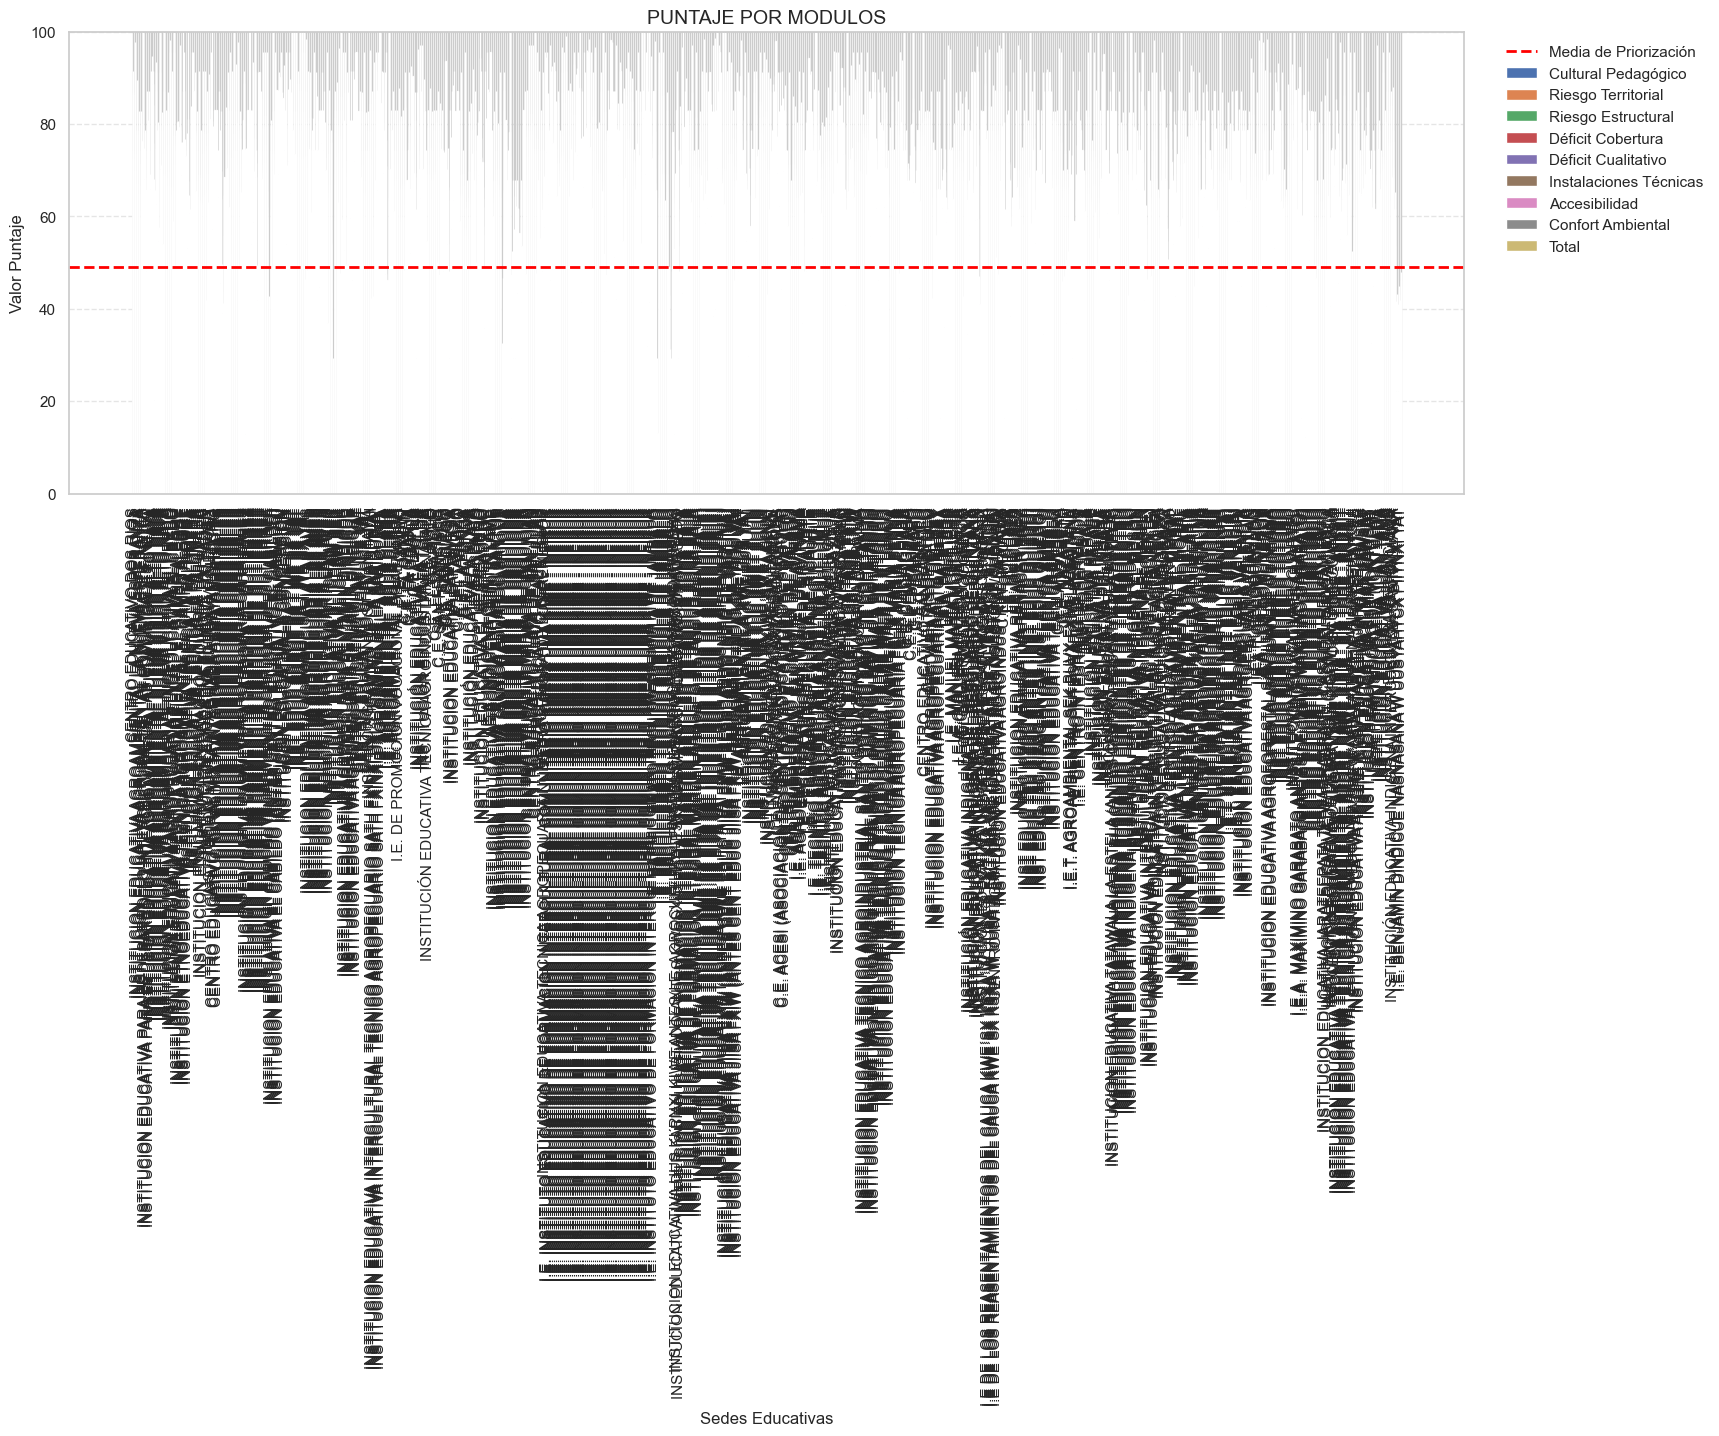

In [212]:
n = len(df['Nombre'])

# Aumentar separación entre sedes
x = np.arange(n) * 3

# Barras más delgadas
width = 0.12

plt.figure(figsize=(18,6))

plt.bar(x - 4*width, df['Puntaje_CULTURAL_PEDAGOGICO'], width, label='Cultural Pedagógico')
plt.bar(x - 3*width, df['Puntaje_RIESGO_TERRITORIAL'], width, label='Riesgo Territorial')
plt.bar(x - 2*width, df['Puntaje_RIESGO_ESTRUCTURAL'], width, label='Riesgo Estructural')
plt.bar(x - width, df['Puntaje_DEFICIT_COBERTURA'], width, label='Déficit Cobertura')
plt.bar(x, df['Puntaje_DEFICIT_CUALITATIVO'], width, label='Déficit Cualitativo')
plt.bar(x + width, df['Puntaje_INSTALACIONES_TECNICAS'], width, label='Instalaciones Técnicas')
plt.bar(x + 2*width, df['Puntaje_ACCESIBILIDAD'], width, label='Accesibilidad')
plt.bar(x + 3*width, df['Puntaje_CONFORT_AMBIENTAL'], width, label='Confort Ambiental')
plt.bar(x + 4*width, df['Puntaje_TOTAL'], width, label='Total')

plt.title('PUNTAJE POR MODULOS', fontsize=14)
plt.xlabel('Sedes Educativas')
plt.ylabel('Valor Puntaje')

plt.xticks(x, df['Nombre'], rotation=90)
plt.ylim(0,100)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.axhline(
    y=49,
    linestyle='--',
    linewidth=2,
    color='red',
    label='Media de Priorización'
)

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

## RESUMEN DE SEDES POR CATEGORIA 

In [213]:
# Menores de 30
sin_diligenciar = df[df['Puntaje_TOTAL'] < 30]

# Cercanas a 49 (por ejemplo ±5 puntos)
cerca_49 = df[
    (df['Puntaje_TOTAL'] >= 44) &
    (df['Puntaje_TOTAL'] <= 54)
]

# Entre 49 y 74
entre_49_74 = df[
    (df['Puntaje_TOTAL'] > 49) &
    (df['Puntaje_TOTAL'] < 74)
]

# Entre 74 y 100
entre_74_100 = df[
    (df['Puntaje_TOTAL'] >= 74) &
    (df['Puntaje_TOTAL'] <= 100)
]

print("Menor de 30:",len(sin_diligenciar))
print("Cerca de 49:",len(cerca_49))
print("Entre 49 y 74:",len(entre_49_74))
print("Entre 74 y 100:",len(entre_74_100))

Menor de 30: 13
Cerca de 49: 48
Entre 49 y 74: 553
Entre 74 y 100: 35


## GRÁFICO DE RESUMEN CANTIDAD DE SEDES POR CATEGORIA
sedes que esten por debajo de 30 puntos no se tienen en cuenta para la priorización esto al considerarse sedes que no completaron el proceso de caracterización.

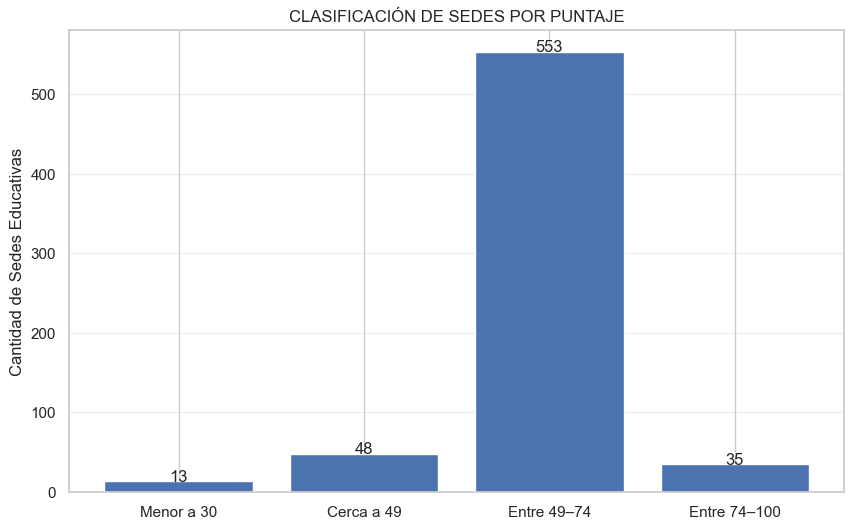

In [214]:
import matplotlib.pyplot as plt

categorias = [
    "Menor a 30",
    "Cerca a 49",
    "Entre 49–74",
    "Entre 74–100"
]

valores = [
    len(sin_diligenciar),
    len(cerca_49),
    len(entre_49_74),
    len(entre_74_100)
]

plt.figure(figsize=(10,6))

barras = plt.bar(categorias, valores)

plt.title("CLASIFICACIÓN DE SEDES POR PUNTAJE")
plt.ylabel("Cantidad de Sedes Educativas")

# etiquetas encima
for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x()+barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center'
    )

plt.grid(axis='y',alpha=0.3)

plt.show()

## SEDES SIN DILIGENICIAR
##### Sedes que tiene menos del 30% de la ficha diligenciada

In [215]:
print("SEDES SIN DILIGENCIAMIENTO")
sin_diligenciar[['Nombre Sede','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10)

SEDES SIN DILIGENCIAMIENTO


,Nombre Sede,Puntaje_TOTAL
103,CENTRO DOCENTE RURAL MIXTO FILADELFIA,13.09805
270,I.E. BACHILLERATO TECNICO AGRICOLA DE JAMBALO,13.152787
277,CENTRO DOCENTE RURAL MIXTO SAN ANTONIO,14.613647
70,ESCUELA RURAL MIXTA EL PLAYON,15.522039
190,CENTRO DOCENTE RURAL MIXTO SANTA RITA,22.020611
46,ESCUELA RURAL MIXTA BUENAVISTA,23.219523
276,CENTRO DOCENTE RURAL MIXTO LOMA LARGA,23.310742
131,CENTRO RURAL MIXTO MATECANA,23.49968
390,INSTITUTO TECNICO ETNO ECOLOGICO VITONCO (SEDE PRINCIPAL),24.663082
436,SEDE ALTO PESARES,27.643541


## SEDES ENTRE 49 Y 74 PUNTOS

In [216]:
print("SEDES ENTRE 49 Y 74 PUNTOS")
entre_49_74[['Nombre Sede', 'Zona','Resguardo', 'Municipio', 'Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10)

SEDES ENTRE 49 Y 74 PUNTOS


,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
479,C.E. NAZARETH - SEDE PRINCIPAL,ZONA ORIENTE,PITAYO,SILVIA,49.045907
608,ESCUELA RURAL MIXTA AMBIWASI,ZONA TANDACHIRIDU WASI,CAUCAPA PUNGO,PIAMONTE,49.359048
47,ESCUELA RURAL MIXTA MIRAVALLE,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,49.72368
172,C.E. LA FONDA - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,49.828114
534,CENRO DOCETE RURAL MIXTO SAN JULIAN,0,0,0,50.004354
138,I.E. TORIBIO - SEDE PRINCIPAL,ZONA NORTE,TORIBIO,TORIBIO,50.503686
501,CENTRO DOCENTE RURAL MIXTO EL BAHO,ZONA ORIENTE,POLINDARA,TOTORO,50.807612
638,ESCUELA RIGCHARIKUNA,ZONA TANDACHIRIDU WASI,RICCHARICUNA,SANTA ROSA,50.862251
494,ESCUELA SAN ANTONIO,ZONA ORIENTE,PANIQUITA,TOTORO,50.904234
318,ESCUELA RURAL MIXTA LOMA ALTA,TIERRA DENTRO,SAN ANDRÉS,INZA,51.303006


## SEDES CERCA A 49 PUNTOS RANGO DE 5%
##### Sedes con alto puntaje de priorización por estar mas cerca al puntaje mas bajo de calificación

In [217]:
print('TOP 10 SEDES CERCA A 49 PUNTOS')
cerca_49[['Nombre','Zona', 'Resguardo', 'Municipio','Puntaje_TOTAL']].sort_values('Puntaje_TOTAL').head(10).sort_values(by='Puntaje_TOTAL')

TOP 10 SEDES CERCA A 49 PUNTOS


,Nombre,Zona,Resguardo,Municipio,Puntaje_TOTAL
416,INSTITUCION EDUCATIVA AGROPECUARIA ALTO DEL REY,ZONA CENTRO,ALTO DEL REY,EL TAMBO,44.326631
181,INSTITUCION EDUCATIVA EL SESTEADERO,ZONA NORTE,TORIBIO,TORIBIO,44.544997
610,CENTRO EDUCATIVO PUERTO GUAYUYACO,ZONA TANDACHIRIDU WASI,TANDARIDU,PAEZ,44.595262
110,INSTITUCION EDUCATIVA AGROPECUARIA BENJAMIN DINDICUE,ZONA NORTE,MUNCHIQUE LOS TIGRES,SANTANDER DE QUILICHAO,44.711288
449,C.E. TUMBURAO,ZONA ORIENTE,TUMBURAO,SILVIA,45.060058
58,INSTITUCION EDUCATIVA CARMENCITA CARDONA DE GUTIERREZ,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,45.486898
521,INSTITUCION EDUCATIVA INDIGENA EL MESON,ZONA UH WALA VXIC,HONDURAS,MORALES,45.564042
141,C.E. EL DAMIAN,ZONA NORTE,TACUEYO,TORIBIO,46.025163
399,C.E. CHICHIGUARA,ZONA CENTRO,PURACÉ,PURACE,46.062452
356,I.E. TECNICO AGROPECUARIA ANGELINA GULLUMUZ,TIERRA DENTRO,TOGOIMA,PAEZ,46.100728


## SEDES ZONA NORTE MAS CERCA A 49 PUNTOS

In [218]:
print('SEDES NORTE')
cerca_49_norte = cerca_49[(cerca_49['Zona'] == 'ZONA NORTE') & (cerca_49['Puntaje_TOTAL'] >= 49)]
filtrado_cerca_49_norte = cerca_49_norte[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(10).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_norte

SEDES NORTE


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
47,219212000177,ESCUELA RURAL MIXTA MIRAVALLE,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,49.72368
172,219821000400,C.E. LA FONDA - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,49.828114
138,119821000031,I.E. TORIBIO - SEDE PRINCIPAL,ZONA NORTE,TORIBIO,TORIBIO,50.503686
51,219212000339,COLEGIO RURAL AGROPECUARIO CARRIZALES (E.R.M. CARRIZALES),ZONA NORTE,PAÉZ DE CORINTO,CORINTO,51.550053
177,219821000426,CENTRO DOCENTE RURAL MIXTO BELEN,ZONA NORTE,TORIBIO,TORIBIO,51.620239
11,219110001438,ESCUELA RURAL MIXTA LA VEGA NAYA,ZONA NORTE,NAYA,BUENOS AIRES,52.14165
160,219821000175,C.E. SAN DIEGO - SEDE PRINCIPAL,ZONA NORTE,TACUEYO,TORIBIO,52.880805
59,219212000126,ESCUELA RURAL MIXTA LOS ALPES,ZONA NORTE,PAÉZ DE CORINTO,CORINTO,53.947335
15,219110001756,ESCUELA RURAL MIXTA RIO MINA - SEDE PRINCIPAL,ZONA NORTE,NAYA,BUENOS AIRES,53.976118


In [219]:
# Guardar datos en excel zona norte

filtrado_cerca_49_norte.to_excel("Sedes_a_priorizar_Zona_Norte.xlsx", index=False)


## SEDES ZONA CENTRO MAS CERCA A 49 PUNTOS 

In [220]:
print('SEDES CENTRO')
cerca_49_centro = cerca_49[cerca_49['Zona'] == 'ZONA CENTRO']
filtrado_cerca_49_centro = cerca_49_centro[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(10).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_centro

SEDES CENTRO


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
416,219256000239,I.E. AGROPECUARIA ALTO DEL REY - SEDE PRINCIPAL,ZONA CENTRO,ALTO DEL REY,EL TAMBO,44.326631
399,219585000665,ESCUELA RURAL MIXTA CHAPIO,ZONA CENTRO,PURACÉ,PURACE,46.062452
400,219585000479,ESCUELA RURAL MIXTA TABIO,ZONA CENTRO,PURACÉ,PURACE,47.486749
438,219001001290,SEDE EL CANELO PARCELACION,ZONA CENTRO,QUINTANA,POPAYAN,51.329809
413,219256001600,ESCUELA LA PRADERA,ZONA CENTRO,ALTO DEL REY,EL TAMBO,52.682796


In [221]:
# Guardar datos Zona centro A

filtrado_cerca_49_centro.to_excel("Sedes_a_priorizar_Zona_Centro_1.xlsx", index=False)

In [222]:
entre_49_74_centro = entre_49_74[entre_49_74['Zona'] == 'ZONA CENTRO']
filtrado_cerca_49_centro_2 = entre_49_74_centro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(5).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_centro_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
403,219585000673,C.E. PISANRABO - SEDE PRINCIPAL,ZONA CENTRO,KOKONUKO,PURACE,54.084472
397,219585000142,C.E. CHICHIGUARA,ZONA CENTRO,PURACÉ,PURACE,54.334391
404,219585000622,ESCUELA RURAL MIXTA COBALO,ZONA CENTRO,KOKONUKO,PURACE,55.361902
398,219585000011,ESCUELA RURAL MIXTA ALTO DE ANAMBIO,ZONA CENTRO,PURACÉ,PURACE,65.467007
401,219585000100,C.E. EL EMPALIZADO - SEDE PRINCIPAL,ZONA CENTRO,PALETARÁ,PURACE,68.667295


In [223]:
filtrado_cerca_49_centro_2.to_excel("Sedes_a_priorizar_Zona_Centro_2.xlsx", index=False)

## SEDES ZONA TIERRADENTRO MAS CERCA A 49 PUNTOS

SEDES JUAN TAMA

In [224]:
print('SEDES TIERRADENTRO (A.C.I Juan Tama)')
cerca_49_tierradentro = cerca_49[(cerca_49['Zona'] == 'TIERRA DENTRO') & (cerca_49['Municipio'] == 'INZA')]
filtrado_cerca_49_juan_tama = cerca_49_tierradentro[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_juan_tama

SEDES TIERRADENTRO (A.C.I Juan Tama)


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
318,219355000046,ESCUELA RURAL MIXTA LOMA ALTA,TIERRA DENTRO,SAN ANDRÉS,INZA,51.303006


In [225]:
# Guardar datos de Juan Tama #1
filtrado_cerca_49_juan_tama.to_excel("Sedes_a_priorizar_Juan_Tama_1.xlsx", index=False)

In [226]:
entre_49_74_tierradentro = entre_49_74[entre_49_74['Zona'] == 'TIERRA DENTRO']
filtrado_cerca_49_juan_tama_2 = entre_49_74_tierradentro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(9).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_juan_tama_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
309,219355001051,ESCUELA RURAL MIXTA EL GUADUAL,TIERRA DENTRO,YAQUIVA,INZA,61.209637
304,219355000062,ESCUELA RURAL MIXTA LOS NARANJOS DEL CABUYO,TIERRA DENTRO,YAQUIVA,INZA,62.742205
310,219355800000,ESCUELA RURAL MIXTA ÜUS DXI`CAMINO DE SABIDURIA,TIERRA DENTRO,YAQUIVA,INZA,65.776321
306,219355000313,ESCUELA RURAL MIXTA CHICHUCUE,TIERRA DENTRO,YAQUIVA,INZA,66.635575
312,219355000232,ESCUELA RURAL MIXTA BELENCITO,TIERRA DENTRO,LA GAITANA JUAN TAMA,INZA,68.392264
311,419355000223,ESCUELA RURAL MIXTA YAQUIVA,TIERRA DENTRO,YAQUIVA,INZA,72.099304
305,219355000283,ESCUELA RURAL MIXTA LA MILAGROSA,TIERRA DENTRO,YAQUIVA,INZA,72.404066
307,219355000321,ESCUELA RURAL MIXTA COSCURO,TIERRA DENTRO,YAQUIVA,INZA,73.655532
308,219355000976,ESCUELA RURAL MIXTA DOS QUEBRADAS,TIERRA DENTRO,YAQUIVA,INZA,73.678565


In [227]:
# Guardar datos de Juan Tama #2
filtrado_cerca_49_juan_tama_2.to_excel("Sedes_a_priorizar_Juan_Tama_2.xlsx", index=False)

SEDES Nasa Çxhâçxha

In [228]:
print('SEDES TIERRADENTRO (Nasa Çxhâçxha)')
cerca_49_tierradentro = cerca_49[(cerca_49['Zona'] == 'TIERRA DENTRO') & (cerca_49['Municipio'] == 'PAEZ')]
filtrado_cerca_49_nasacxacxa_1 = cerca_49_tierradentro[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_nasacxacxa_1

SEDES TIERRADENTRO (Nasa Çxhâçxha)


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
356,219517800017,ESCUELA RURAL MIXTA PIYA YAT EL CHUMAL,TIERRA DENTRO,TOGOIMA,PAEZ,46.100728
389,219517001670,ESCUELA RURAL MIXTA TIERRAS BLANCAS,TIERRA DENTRO,LAME,PAEZ,47.043181
643,219517000452,ESCUELA RURAL MIXTA SANTA MARTA,TIERRA DENTRO,MOSOCO,PAEZ,48.811961
338,219517000169,ESCUELA EL CARMEN DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,51.666385
346,219517000428,CENTRO DOCENTE LA HONDA,TIERRA DENTRO,RICAURTE,PAEZ,53.888238


In [229]:
# Guardar datos Nasa Cxa Cxa #1
filtrado_cerca_49_nasacxacxa_1.to_excel("Sedes_a_priorizar_Nasa_CxaCxa.xlsx")

In [230]:
entre_49_74_tierradentro_2 = entre_49_74[(entre_49_74['Zona'] == 'TIERRA DENTRO') & (entre_49_74['Municipio'] == 'PAEZ')]
filtrado_cerca_49_nasacxacxa_2 = entre_49_74_tierradentro_2[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(8).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_nasacxacxa_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
338,219517000169,ESCUELA EL CARMEN DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,51.666385
337,219517800009,ESCUELA RURAL MIXTA MESA DE BELALCAZAR,TIERRA DENTRO,BELALCAZAR,PAEZ,57.878276
341,219517000045,ESCUELA RURAL MIXTA SAN ANTONIO DEL SALADO,TIERRA DENTRO,BELALCAZAR,PAEZ,58.790418
342,219517000568,ESCUELA RURAL MIXTA AGUA BENDITA,TIERRA DENTRO,AVIRAMA,PAEZ,59.568535
340,219517001076,ESCUELA RURAL MIXTA POTRERO DEL BARRO,TIERRA DENTRO,BELALCAZAR,PAEZ,60.769742
335,219517000550,ESCUELA RURAL MIXTA EL RODEO,TIERRA DENTRO,BELALCAZAR,PAEZ,68.719269
336,219517000720,ESCUELA RURAL MIXTA LA MARIA,TIERRA DENTRO,TÁLAGA,PAEZ,70.043541
334,219517000151,C.E. ACESI (ASOCIACION DE CENTROS EDUCATIVOS DEL SIMBOLA) - SEDE PRINCIPAL,TIERRA DENTRO,BELALCAZAR,PAEZ,72.499334


In [231]:
# Guardar datos Nasa Cxa Cxa #2
filtrado_cerca_49_nasacxacxa_2.to_excel("Sedes_a_priorizar_Nasa_CxaCxa_2.xlsx")

## SEDES PUEBLO YANACONA MAS CERCA A 49 PUNTOS

In [232]:
print('SEDES PUEBLO YANACONA')
cerca_49_sur = cerca_49[(cerca_49['Zona'] == 'ZONA SUR') & (cerca_49['Pueblo'] == 'Pueblo Yanakuna')]
filtrado_cerca_49_yanacona_1 = cerca_49_sur[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(4)
filtrado_cerca_49_yanacona_1

SEDES PUEBLO YANACONA


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
202,219022001061,ESCUELA RURAL MIXTA EL POTRERO,ZONA SUR,CAQUIONA,ALMAGUER,47.52366
538,219392000102,ESCUELA RURAL MIXTA LOS ROBLES,ZONA SUR,EL MORAL,LA SIERRA,53.024816


In [233]:
# Guardar datos de Yanacona
filtrado_cerca_49_yanacona_1.to_excel("Sedes_a_priorizar_Yanacona_1.xlsx", index=False)

In [234]:
print('SEDES EDUCATIVAS PUEBLO YANACONA ENTRE 49 Y 74 PUNTOS')
entre_49_74_sur_2 = entre_49_74[(entre_49_74['Zona'] == 'ZONA SUR') & (entre_49_74['Puntaje_TOTAL'] < 60)]
filtrado_cerca_49_yanacona_2 = entre_49_74_sur_2[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(6).sort_values(by='Puntaje_TOTAL')
filtrado_cerca_49_yanacona_2

SEDES EDUCATIVAS PUEBLO YANACONA ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
538,219392000102,ESCUELA RURAL MIXTA LOS ROBLES,ZONA SUR,EL MORAL,LA SIERRA,53.024816
539,219392000391,ESCUELA RURAL MIXTA CAMPOBELLO,ZONA SUR,EL MORAL,LA SIERRA,56.98918
193,219022000189,ESCUELA RURAL MIXTA DOMINGUILLO,ZONA SUR,CAQUIONA,ALMAGUER,57.413772
537,219392000021,ESCUELA RURAL MIXTA EL SALERO,ZONA SUR,EL MORAL,LA SIERRA,58.209871
210,219100000930,ESCUELA RURAL MIXTA CIMARRONAS NUEVA GRANADA,ZONA SUR,SAN JUAN,BOLIVAR,59.315909
536,119392001147,ESCUELA RURAL MIXTA AMOR POR LO NUESTRO,ZONA SUR,PUERTAS DEL MACIZO,LA SIERRA,59.932447


In [235]:
# Guardar datos de Yanacona_2
filtrado_cerca_49_yanacona_2.to_excel("Sedes_a_priorizar_Yanacona_2.xlsx", index=False)

## SEDES EDUCATIVAS SAT´H TAMA KIWE CERCA DE 49 PUNTOS 
##### No hay sedes que esten en el rango del 5% a 49 puntos

In [236]:
print('SEDES SATH TAMA KIWE CERCA A 49 PUNTOS')
cerca_49_stk = cerca_49[(cerca_49['Zona'] == 'ZONA SATH TAMA KIWE')]
cerca_49_stk[['Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']]

SEDES SATH TAMA KIWE CERCA A 49 PUNTOS


,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL


## SEDES EDUCATIVAS SAT´H TAMA KIWE ENTRE 49 Y 74 PUNTOS 

In [237]:
print('SEDES EDUCATIVAS SATH TAMA KIWE ENTRE 49 Y 74 PUNTOS')
entre_49_74_stk = entre_49_74[(entre_49_74['Zona'] == 'ZONA SATH TAMA KIWE') & (entre_49_74['Puntaje_TOTAL'] < 60)]
filtro_sedes_stk = entre_49_74_stk[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(6).sort_values(by='Puntaje_TOTAL')
filtro_sedes_stk

SEDES EDUCATIVAS SATH TAMA KIWE ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
252,219137001260,CENTRO DOCENTE RURAL MIXTO SAN JOSE DE LOS MONOS,ZONA SATH TAMA KIWE,PUEBLO NUEVO,CALDONO,54.707712
242,219137001111,CENTRO DOCENTE RURAL MIXTO SAN PEDRO,ZONA SATH TAMA KIWE,PUEBLO NUEVO,CALDONO,56.005284
220,219137000204,INSTITUTO EDUCATIVO TÉCNICO AGRÍCOLA KWESX DXIJ PLAN DE ZÚÑIGA,ZONA SATH TAMA KIWE,SAN LORENZO,CALDONO,56.040618
262,219137001529,ESC RUR MIX LA LAGUNA BILINGUE,ZONA SATH TAMA KIWE,LA LAGUNA,CALDONO,57.191077
249,219137001227,CENTRO DOCENTE VILLA RICA,ZONA SATH TAMA KIWE,LA AGUADA - SAN ANTONIO,CALDONO,58.230024


In [238]:
filtro_sedes_stk.to_excel("Sedes_a_priorizar_Sat´h_Tama_Kiwe.xlsx", index=False)

## SEDES EDUCATIVAS COTAINDOC CERCA DE LOS 49 PUNTOS

In [239]:
print('SEDES ZONA ORIENTE COTAINDOC')
cerca_49_oriente = cerca_49[(cerca_49['Zona'] == 'ZONA ORIENTE')]
filtro_COTAINDOC = cerca_49_oriente[['Código DANE Sede', 'Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(10)
filtro_COTAINDOC

SEDES ZONA ORIENTE COTAINDOC


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
449,219743000031,CRISTO REY - SEDE PRINCIPAL,ZONA ORIENTE,TUMBURAO,SILVIA,45.060058
472,219743000180,CENTRO DOCENTE RURAL MIXTO MIRAFLORES,ZONA ORIENTE,AMPIUILE,SILVIA,48.732613
479,219743000511,C.E. NAZARETH - SEDE PRINCIPAL,ZONA ORIENTE,PITAYO,SILVIA,49.045907
501,219824000427,CENTRO DOCENTE RURAL MIXTO EL BAHO,ZONA ORIENTE,POLINDARA,TOTORO,50.807612
494,219824000095,ESCUELA SAN ANTONIO,ZONA ORIENTE,PANIQUITA,TOTORO,50.904234
454,419743001096,CENTRO DOCENTE RURAL MIXTO GOLONDRINAS,ZONA ORIENTE,QUICHAYA,SILVIA,51.787051
506,219824800017,LA PRIMAVERA,ZONA ORIENTE,PANIQUITA,TOTORO,53.463491


In [240]:
# Guardar datos COTAINDOC
filtro_COTAINDOC.to_excel("Sedes_a_priorizar_COTAINDOC.xlsx", index=False)

## SEDES PUEBLO TOTOROEZ CERCA DE LOS 49 PUNTOS

In [241]:
print('SEDES EDUCATIVAS PUEBLO TOTOROEZ')
cerca_49_pt = cerca_49[(cerca_49['Zona'] == 'PUEBLO TOTOROEZ') ]
filtro_totoro_1 = cerca_49_pt[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL')
filtro_totoro_1

SEDES EDUCATIVAS PUEBLO TOTOROEZ


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
594,219824000494,CENT DOC RUR MIX PUENTE TIERRA,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,52.015348


In [242]:
filtro_totoro_1.to_excel("Sedes_a_priorizar_Totoro_1.xlsx", index=False)

## SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS

In [243]:
print('SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS')
entre_49_74_pt = entre_49_74[(entre_49_74['Zona'] == 'PUEBLO TOTOROEZ')]
filtro_totoro_2 = entre_49_74_pt[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(4).sort_values(by='Puntaje_TOTAL')
filtro_totoro_2

SEDES EDUCATIVAS PUEBLO TOTOROEZ ENTRE 49 Y 74 PUNTOS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
591,219824000320,CENTRO DOCENTE RURAL MIXTO NUEVA ORLEANS,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,63.414354
588,219824000010,ESCUELA RURAL MIXTA EL COFRE,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,64.524294
590,219824000273,CENTRO DOCENTE RURAL MIXTO MIRAFLORES,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,71.277503
589,219824000044,CENTRO DOCENTE EL CARMEN ZABALETAS,PUEBLO TOTOROEZ,TOTORÓ,TOTORO,73.796799


In [244]:
filtro_totoro_2.to_excel("Sedes_a_priorizar_Totoro_2.xlsx", index=False)

## SEDES EDUCATIVAS UH WALA VXIC CERCA DE 49 PUNTOS

In [245]:
cerca_49_uwv = cerca_49[(cerca_49['Zona'] == 'ZONA UH WALA VXIC')]
filtro_uwv_1 = cerca_49_uwv[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL')
filtro_uwv_1

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
521,219473000701,ESCUELA RURAL MIXTA LOMITAS,ZONA UH WALA VXIC,HONDURAS,MORALES,45.564042
522,219473006717,ESCUELA RURAL MIXTA BELEN,ZONA UH WALA VXIC,HONDURAS,MORALES,46.366315
524,219473000531,ESCUELA RURAL MIXTA PUEBLILLO,ZONA UH WALA VXIC,HONDURAS,MORALES,47.049232


In [246]:
filtro_uwv_1.to_excel("Sedes_a_priorizar_UhWalaVixc_1.xlsx", index=False)

In [247]:
entre_49_74_uwv = entre_49_74[(entre_49_74['Zona'] == 'ZONA UH WALA VXIC')]
filtro_uwv_2 = entre_49_74_uwv[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].sort_values(by='Puntaje_TOTAL').head(8)
filtro_uwv_2

,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
531,219473000760,ESCUELA AA. CIPO LA LIBERIA,ZONA UH WALA VXIC,CHIMBORAZO,MORALES,57.413122
529,419473006392,ESCUELA RURAL MIXTA SAMARIA,ZONA UH WALA VXIC,AGUA NEGRA,MORALES,58.209397
510,219473000719,ESCUELA RURAL MIXTA LAS BRISAS,ZONA UH WALA VXIC,HONDURAS,MORALES,60.451059
507,219473000018,ESCUELA RURAL DE TIERRA DENTRO,ZONA UH WALA VXIC,HONDURAS,MORALES,60.529775
525,219473000573,ESCUELA RURAL MIXTA MEDELLIN,ZONA UH WALA VXIC,HONDURAS,MORALES,61.121647
515,219473006687,KWE´SX KIWE,ZONA UH WALA VXIC,HONDURAS,MORALES,61.598948
512,219473000743,ESCUELA RURAL MIXTA EL JORDAN,ZONA UH WALA VXIC,HONDURAS,MORALES,61.73415
518,219473000221,ESCUELA RURAL MIXTA SAN JOSE DE CAUCA,ZONA UH WALA VXIC,HONDURAS,MORALES,61.906177


In [248]:
filtro_uwv_2.to_excel("Sedes_a_priorizar_UhWalaVixc_2.xlsx", index=False)

## SEDES ZONA NASA UUS CERCA DE 49 PUNTOS
##### No hay sedes cerca de 49 puntos

In [249]:

cerca_49_nu = cerca_49[(cerca_49['Zona'] == 'ZONA NASA UUS')]
cerca_49_nu[['Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head().sort_values(by='Puntaje_TOTAL')

,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL


## SEDES ZONA NASA USS ENTRE 49 Y 74 PUNTOS

In [250]:

print('SEDES NASA USS')
entre_49_74_nu = entre_49_74[(entre_49_74['Zona'] == 'ZONA NASA UUS')]
filtro_nasauus = entre_49_74_nu[['Código DANE Sede','Nombre Sede', 'Zona','Resguardo','Municipio','Puntaje_TOTAL']].head(4).sort_values(by='Puntaje_TOTAL')
filtro_nasauus

SEDES NASA USS


,Código DANE Sede,Nombre Sede,Zona,Resguardo,Municipio,Puntaje_TOTAL
440,219130003658,ESCUELA RURAL MIXTA SAN JOSE DEL GUAYABAL,ZONA NASA UUS,CXAYU CE FXIW,CAJIBIO,59.702411
444,219760000690,E.R.M. EL PEÑÓN,ZONA NASA UUS,EL PEÑON,POPAYAN,63.37491
443,219473006491,E.R.M. SEMILLERO DE NIÑOS PAECES (LUUCX FXIW) - SEDE PRINCIPAL,ZONA NASA UUS,MUSSE UKWE,MORALES,73.285351
441,219130003739,PATHYU LUUCX,ZONA NASA UUS,PATH YU,CAJIBIO,73.857191


In [251]:
filtro_nasauus.to_excel("Sedes_a_priorizar_NasaUus.xlsx", index=False)

## DESCRIPCIÓN ESTADISTICA DE LOS DATOS 

In [252]:
puntaje = df['Puntaje_TOTAL']

print("Cantidad:", puntaje.count())
print("Promedio:", round(puntaje.mean(),2))
print("Mediana:", round(puntaje.median(),2))
print("Moda:", puntaje.mode().values)
print("Mínimo:", round(puntaje.min(),2))
print("Máximo:", round(puntaje.max(), 2))

print("Desviación estándar:",
    round(puntaje.std(),2))

print("Varianza:",
    round(puntaje.var(),2))

print("Cuartil 25:",
    round(puntaje.quantile(0.25),2))

print("Cuartil 75:",
    round(puntaje.quantile(0.75),2))

print("P10:",puntaje.quantile(.10))
print("P25:",puntaje.quantile(.25))
print("P50:",puntaje.quantile(.50))
print("P75:",puntaje.quantile(.75))
print("P90:",puntaje.quantile(.90))

Cantidad: 654
Promedio: 62.41
Mediana: 64.5
Moda: [13.098050431034483 13.152787499999999 14.613647413793103
 15.522039137931035 22.020610775862067 23.219522844827587
 23.31074224137931 23.49967974137931 24.663081896551724 27.64354103448276
 28.107177068965516 29.006697586206897 29.429991896551726
 31.11455474137931 31.283977155172416 31.407015862068967 31.99027629310345
 34.11483922413793 35.21927103448276 35.89130689655173 36.01226879310345
 36.16240405172414 36.85840655172414 36.952205000000006 37.96791353448276
 38.121143706896554 38.82555586206897 39.45361939655172 40.90748956896552
 40.92170129310345 40.94701163793104 41.037794741379315 41.206349568965514
 41.39212232758621 41.457394482758616 41.58146517241379 41.63624198275862
 41.876205517241374 42.59579353448276 43.18319474137931 43.37324068965518
 43.7803375862069 43.92413870689655 44.32663129310345 44.544997499999994
 44.59526224137932 44.71128801724139 45.060058017241374 45.486897500000005
 45.564041637931034 46.025162586206

## GRÁFICO DE TENDENCIAS DIVIDIDO EN PERCENTILES

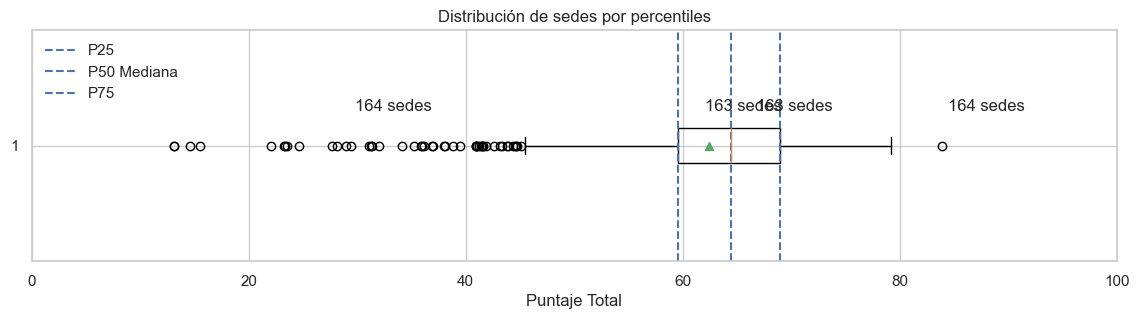

In [253]:
import matplotlib.pyplot as plt

puntaje = df['Puntaje_TOTAL'].dropna()

# Calcular percentiles
p25 = puntaje.quantile(0.25)
p50 = puntaje.quantile(0.50)
p75 = puntaje.quantile(0.75)

# Cantidad de sedes por rango
q1 = len(puntaje[puntaje <= p25])

q2 = len(
    puntaje[
        (puntaje > p25) &
        (puntaje <= p50)
    ]
)

q3 = len(
    puntaje[
        (puntaje > p50) &
        (puntaje <= p75)
    ]
)

q4 = len(puntaje[puntaje > p75])

plt.figure(figsize=(14,3))

plt.boxplot(
    puntaje,
    vert=False,
    showmeans=True
)

# líneas de percentiles
plt.axvline(p25, linestyle='--', label='P25')
plt.axvline(p50, linestyle='--', label='P50 Mediana')
plt.axvline(p75, linestyle='--', label='P75')

# texto con cantidades
plt.text(p25/2,
        1.15,
        f"{q1} sedes")

plt.text((p25+p50)/2,
        1.15,
        f"{q2} sedes")

plt.text((p50+p75)/2,
        1.15,
        f"{q3} sedes")

plt.text((p75+100)/2,
        1.15,
        f"{q4} sedes")

plt.xlim(0,100)

plt.xlabel("Puntaje Total")
plt.title("Distribución de sedes por percentiles")

plt.legend()

plt.show()